<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 10px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 32px; font-weight: 600;">Procesamiento de Imagen en Medicina</h1>
    <h3 style="color: rgba(255,255,255,0.95); margin: 12px 0 0 0; font-size: 16px; font-weight: 400;">Grado en Ciencia e Ingeniería de Datos | UMU - UPCT</h3>
</div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">

### <span style="color: #667eea;">**Práctica 03**</span>
## Registro de Imagen Médica

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">

### Objetivos
- Comprender el problema del registro de imagen y su formulación básica.
- Identificar los componentes fundamentales de un algoritmo de registro:
    - Imagen fija y móvil
    - Transformación
    - Métrica de similitud
    - Algoritmo de optimización
    - Interpolación
- Implementar algoritmos básicos de registro utilizando SimpleITK.
- Experimentar con aplicaciones de registro monomodal y multimodal.

### Contenidos

- [Entorno de Trabajo](#entorno01)
- [Revisión de conceptos](#intro01)
- [Fundamentos de registro de imagen](#basic01)
- [Registro pairwise monomodal (CT-CT)](#monomod01)
- [Registro pairwise multimodal (MR-CT)](#multimod01)

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='entorno01'></a>

## <span style="color: #667eea;">Entorno de Trabajo</span>

### *Kaggle Notebooks*

1. Descarga este notebook desde el Aula Virtual.
2. Accede a [kaggle.com](https://www.kaggle.com) con tu cuenta.
3. Ve a **"Create"** → **"Import Notebook"**.
4. En **"Advanced Settings"** selecciona la opción **"Quick Save"**.
5. Sube el archivo `.ipynb` descargado.
6. Pulsa el botón **"Edit"** para acceder al notebook.
7. ¡Listo! Ejecuta las celdas secuencialmente con `Shift + Enter`.

### *Verificación del entorno*

La siguiente celda verifica que todas las librerías necesarias están instaladas. Si alguna falta, se instalará automáticamente:

In [1]:
# Verificar e instalar librerías automáticamente
import sys

print(f"Python version: {sys.version}")
print("\nVerificando librerías...")

# Instalación silenciosa de librerías faltantes
try:
    import nibabel as nib

    print(f"[OK] nibabel {nib.__version__}")
except ImportError:
    print("[!] Instalando nibabel...")
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nibabel"])
    import nibabel as nib

    print(f"[OK] nibabel {nib.__version__} instalado")

try:
    import ipywidgets

    print(f"[OK] ipywidgets {ipywidgets.__version__}")
except ImportError:
    print("[!] Instalando ipywidgets...")
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets

    print(f"[OK] ipywidgets {ipywidgets.__version__} instalado")

try:
    import SimpleITK as sitk

    print(f"[OK] SimpleITK {sitk.__version__}")
except ImportError:
    print("[!] Instalando SimpleITK...")
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "SimpleITK"])
    import SimpleITK as sitk

    print(f"[OK] SimpleITK {sitk.__version__} instalado")

import numpy as np
import matplotlib.pyplot as plt

print(f"[OK] numpy {np.__version__}")
print(f"[OK] matplotlib {plt.matplotlib.__version__}")

# Verificar que las librerías críticas funcionan
assert sitk is not None, "SimpleITK no disponible"
assert np is not None, "numpy no disponible"

Python version: 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]

Verificando librerías...
[OK] nibabel 5.3.3
[OK] ipywidgets 8.1.8
[OK] SimpleITK 2.5.3
[OK] numpy 2.4.2
[OK] matplotlib 3.10.8


<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='revision01'></a>

## <span style="color: #667eea;">Revisión de Conceptos</span>

En esta práctica abordaremos el problema del registro de imagen médica por pares (pair-wise), es decir, el alineamiento espacial de dos imágenes que representan la misma anatomía.
Plantearemos el problema de registro de foma clásica (NO deep learning): partiendo de un par de imágenes, buscaremos la transformación espacial que las alinea mediante un algoritmo de optimización sobre una determinada métrica de similitud entre las imágenes empleando la librería `SimpleITK`.

El registro es una herramienta fundamental del procesamiento de imagen en medicina en múltiples aplicaciones, como por ejemplo:

* Seguimiento temporal mediante registro monomodal (CT–CT, MR–MR)

* Fusión multimodal (MR–CT, PET–CT)

* Planificación quirúrgica

* Radioterapia

### *Elementos fundamentales del pipeline de registro*

Un algoritmo de registro se compone de los siguientes elementos:

- *Imagen fija (fixed)*: referencia
- *Imagen móvil (moving)*: imagen que se transforma para alinearse con la referencia
- *Transformación*: define cómo se modifica la imagen móvil
- *Métrica de similitud*: cuantifica el grado de alineamiento entre las imágenes
- *Optimizador*: algoritmo que ajusta los parámetros de la transformación
- *Interpolación*: necesaria para obtener la imagen (móvil) transformada, ya que al aplicar la transformación espacial se generan posiciones no enteras de píxel/voxel

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='revision01'></a>

## <span style="color: #667eea;">1. Fundamentos de registro de imagen</span>

### *Generación del phantom*

Utilizaremos el una imagen sintética (Shepp-Logan) para revisar los conceptos básicos del registro de imagen.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

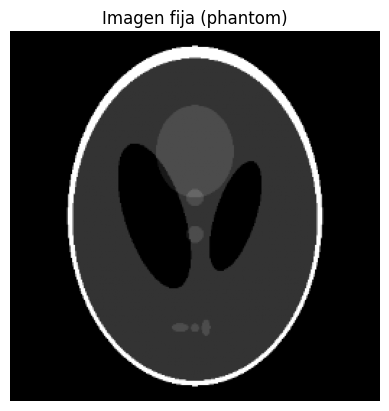

In [2]:
# Phantom 2D
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

phantom_2d = shepp_logan_phantom()
phantom_2d = resize(phantom_2d, (256, 256))
fixed = sitk.GetImageFromArray(phantom_2d.astype(np.float32))
# fixed = sitk.Normalize(fixed);

plt.imshow(sitk.GetArrayFromImage(fixed), cmap="gray")
plt.title("Imagen fija (phantom)")
plt.axis("off")

Aplicamos una deformación conocida sobre el phantom para generar la imagen móvil. En este caso, una transformación rígida 2D (`Euler2DTransform`), con un parámetro de rotación y 2 parámetros de traslación (x,y).

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

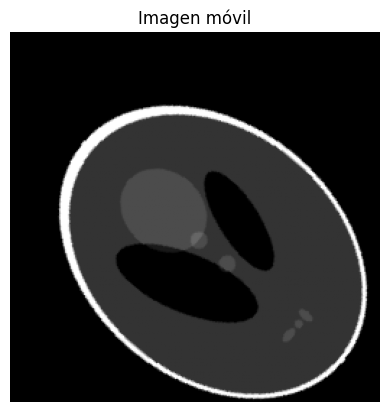

In [3]:
# Transformación rígida real conocida
angle = 50
t_x = 10
t_y = -25
t_rigid2D = sitk.Euler2DTransform()
t_rigid2D.SetAngle(np.deg2rad(angle))
t_rigid2D.SetTranslation((t_x, t_y))
c0 = phantom_2d.shape[0] // 2
c1 = phantom_2d.shape[1] // 2
t_rigid2D.SetCenter(fixed.TransformIndexToPhysicalPoint((c0, c1)))

# Aplicación de la transformación sobre la imagen fija
moving = sitk.Resample(fixed, fixed, t_rigid2D, sitk.sitkLinear, 0.0, sitk.sitkFloat32)

plt.imshow(sitk.GetArrayFromImage(moving), cmap="gray")
plt.title("Imagen móvil")
plt.axis("off")

### *Registro rígido para recuperar parámetros*

Definición básica del método de registro rígido 2D utilizando `SimpleITK`. Como métrica utilizamos la SSD (Sum of Squared Differences, `SetMetricAsMeanSquares`). 

In [4]:
def register_rigid_2d(fixed, moving):

    R = sitk.ImageRegistrationMethod()

    # Establecer métrica (SSD)
    R.SetMetricAsMeanSquares()

    # Parámetros del optimizador (Descenso por gradiente)
    R.SetOptimizerAsRegularStepGradientDescent(
        2.0,  # learningRate
        1e-4,  # minStep
        500,  # numberOfIterations
        0.5,  # relaxationFactor (cómo reduce el paso cuando cambia de dirección)
        1e-8,
    )  # gradientMagnitudeTolerance
    R.SetOptimizerScalesFromIndexShift()
    # Interpolador (lineal)
    R.SetInterpolator(sitk.sitkLinear)
    # Tipo de transformación e inicialización
    initial = sitk.CenteredTransformInitializer(
        fixed,
        moving,
        sitk.Euler2DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )
    R.SetInitialTransform(initial)
    print("Parámetros iniciales de la transformación: ", initial.GetParameters())

    # Opciones de multiresolución y suavizado (3 niveles)
    R.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    R.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])

    # Ejecución del algoritmo
    final = R.Execute(fixed, moving)

    print("-------")
    print("Optimizer stop condition: ", R.GetOptimizerStopConditionDescription())
    print("Iteration: ", R.GetOptimizerIteration())
    print("Metric value: ", R.GetMetricValue())
    print("-------")
    return final

Ejecutamos el registro y comparamos los parámetros estimados con los reales.

Parámetros iniciales de la transformación:  (0.0, 0.0, 0.0)
-------
Optimizer stop condition:  RegularStepGradientDescentOptimizerv4: Step too small after 46 iterations. Current step (6.10352e-05) is less than minimum step (0.0001).
Iteration:  47
Metric value:  0.0009963489989955406
-------
Ángulo real: 50.0
Ángulo estimado: -49.932081220500876
Traslación real: (10.0, -25.0)
Traslación estimada: (12.52041639510089, 24.291861572611218)


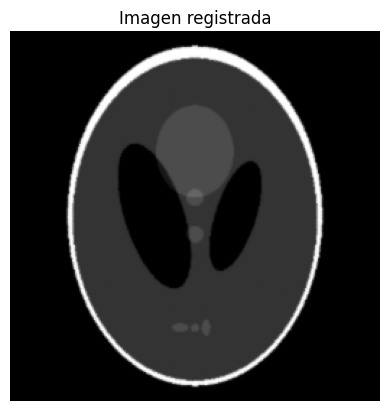

In [5]:
t_reg = register_rigid_2d(fixed, moving)

# Aplicamos la transformación estimada sobre la imagen móvil
moved_rig = sitk.Resample(moving, fixed, t_reg, sitk.sitkLinear, 0.0, sitk.sitkFloat32)

plt.imshow(sitk.GetArrayFromImage(moved_rig), cmap="gray")
plt.title("Imagen registrada")
plt.axis("off")

# Comparamos los parámetros estimados con los reales
print("Ángulo real:", np.rad2deg(t_rigid2D.GetAngle()))
print("Ángulo estimado:", np.rad2deg(t_reg.GetAngle()))

print("Traslación real:", t_rigid2D.GetTranslation())
print("Traslación estimada:", t_reg.GetTranslation())

Visualización del resultado sobre la imagen fija.

Text(0.5, 1.0, 'Imagen fija (G) + registrada (R)')

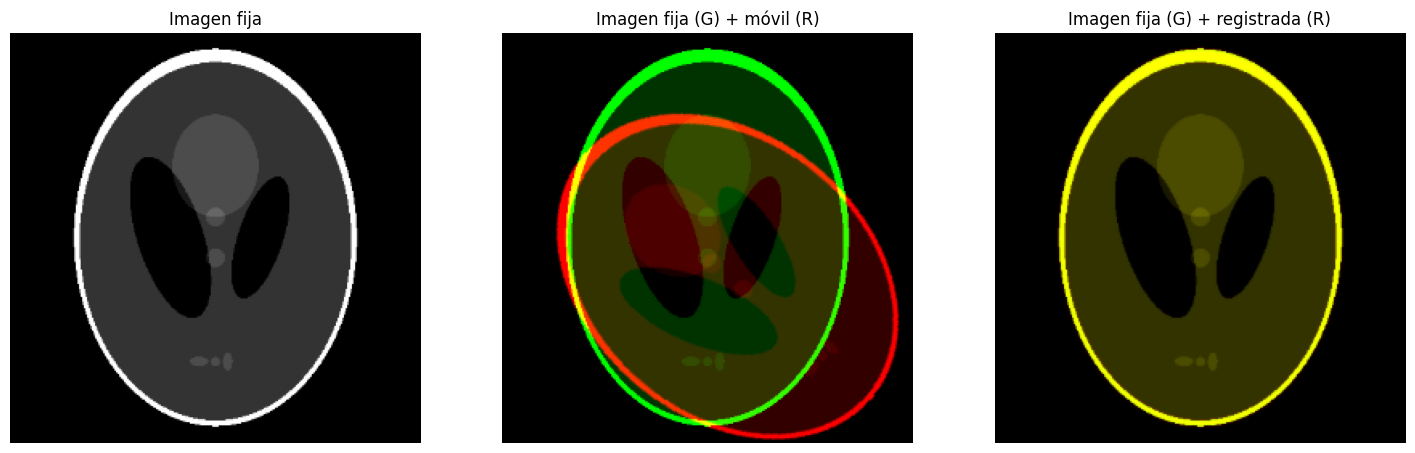

In [6]:
def norm01(x):
    x = x - x.min()
    return x / (x.max() + 1e-8)


def overlay_rg(a, b):
    a = norm01(a)
    b = norm01(b)
    rgb = np.stack([b, a, np.zeros_like(a)], axis=-1)  # R=b, G=a
    return np.clip(rgb, 0, 1)


plt.figure(figsize=(18, 6))

# Imagen fija
If = sitk.GetArrayFromImage(fixed)
plt.subplot(1, 3, 1)
plt.imshow(If, cmap="gray")
plt.axis("off")
plt.title("Imagen fija")

# Imagen fija con imagen móvil superpuesta (pre-registro)
Im = sitk.GetArrayFromImage(moving)
plt.subplot(1, 3, 2)
plt.imshow(overlay_rg(If, Im))
plt.axis("off")
plt.title("Imagen fija (G) + móvil (R)")

# Imagen fija con imagen registrada superpuesta
Ireg = sitk.GetArrayFromImage(moved_rig)
plt.subplot(1, 3, 3)
plt.imshow(overlay_rg(If, Ireg))
plt.axis("off")
plt.title("Imagen fija (G) + registrada (R)")

### *Transformación afín 2D*

Una transformación afín en 2D tiene 6 grados de libertad, permitiendo: traslación, rotación, escalado y cizallamiento.

A continuación, aplicamos una transformación afín 2D (`AffineTransform(2)`) conocida al phantom para después tratar de estimar sus parámetros mediante el algortimo de registro.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

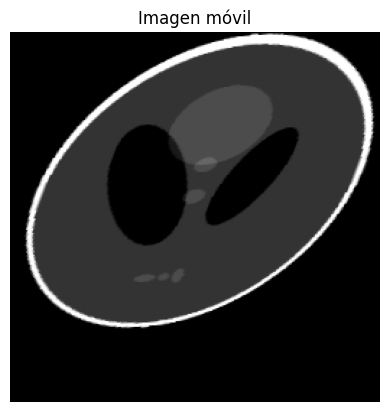

In [7]:
# Definimos la nueva transformación
affine2D = sitk.AffineTransform(2)
center = fixed.TransformIndexToPhysicalPoint((c0, c1))
affine2D.SetCenter(center)

# Matriz (escalado anisotrópico + shear y rotación)
matrix = [0.8, 0.3, 0.1, 1.2]
affine2D.SetMatrix(matrix)

# Traslación
affine2D.SetTranslation((5, 30))

# Aplicación de la transformación sobre la imagen fija
moving_aff = sitk.Resample(
    fixed, fixed, affine2D, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)

plt.imshow(sitk.GetArrayFromImage(moving_aff), cmap="gray")
plt.title("Imagen móvil")
plt.axis("off")

Como primer paso, aplicamos el registro rígido 2D definido previamente para analizar el efecto.

Parámetros iniciales de la transformación:  (0.0, 0.0, 0.0)
-------
Optimizer stop condition:  RegularStepGradientDescentOptimizerv4: Step too small after 338 iterations. Current step (6.10352e-05) is less than minimum step (0.0001).
Iteration:  339
Metric value:  0.05742042608195882
-------


Text(0.5, 1.0, 'Imagen fija (G) + registrada (R)')

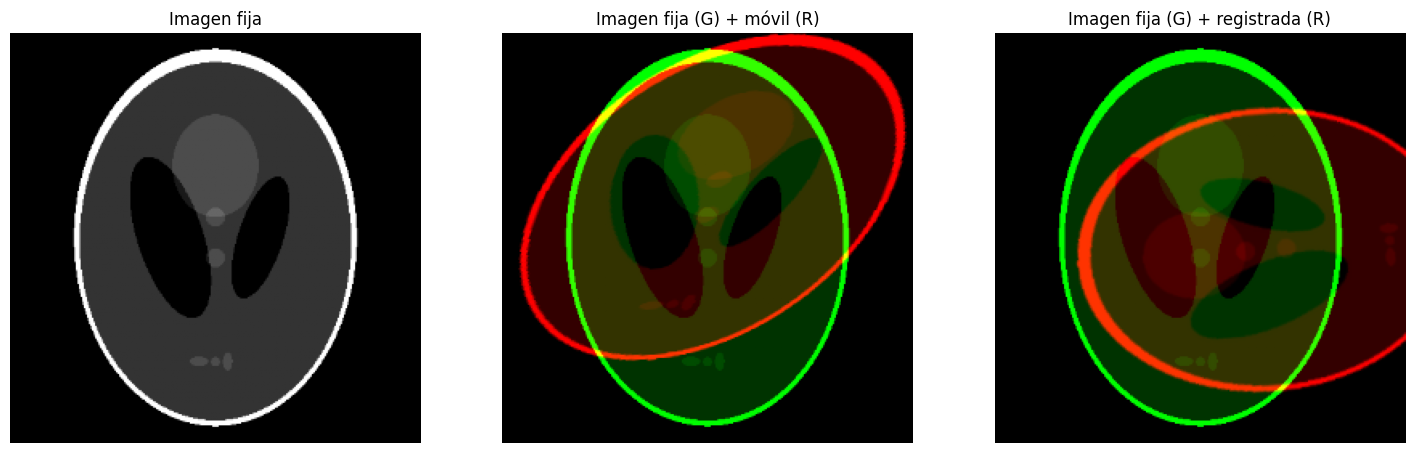

In [8]:
t2 = register_rigid_2d(fixed, moving_aff)

# Aplicamos la transformación estimada sobre la imagen móvil
moved_rig2 = sitk.Resample(moving, fixed, t2, sitk.sitkLinear, 0.0, sitk.sitkFloat32)

plt.figure(figsize=(18, 6))

# Imagen fija
plt.subplot(1, 3, 1)
plt.imshow(If, cmap="gray")
plt.axis("off")
plt.title("Imagen fija")

# Imagen fija con imagen móvil superpuesta (pre-registro)
Im = sitk.GetArrayFromImage(moving_aff)
plt.subplot(1, 3, 2)
plt.imshow(overlay_rg(If, Im))
plt.axis("off")
plt.title("Imagen fija (G) + móvil (R)")

# Imagen fija con imagen registrada superpuesta
Ireg = sitk.GetArrayFromImage(moved_rig2)
plt.subplot(1, 3, 3)
plt.imshow(overlay_rg(If, Ireg))
plt.axis("off")
plt.title("Imagen fija (G) + registrada (R)")

Aplicamos ahora un registro afín 2D y comparamos los parámetros estimados con los reales.

Parámetros iniciales de la transformación:  (1.0, 0.0, 0.0, 1.0, 0.0, 0.0)
-------
Optimizer stop condition:  RegularStepGradientDescentOptimizerv4: Step too small after 48 iterations. Current step (6.10352e-05) is less than minimum step (0.0001).
Iteration:  49
Metric value:  0.0016353053945600327
-------
COMPARACIÓN DE PARÁMETROS
REAL:     [np.float64(0.8), np.float64(0.3), np.float64(0.1), np.float64(1.2), np.float64(5.0), np.float64(30.0)]
ESTIMADO: [np.float64(1.2952), np.float64(-0.3116), np.float64(-0.1205), np.float64(0.8592), np.float64(3.2269), np.float64(-25.2762)]


Text(0.5, 1.0, 'Imagen fija (G) + registrada (R)')

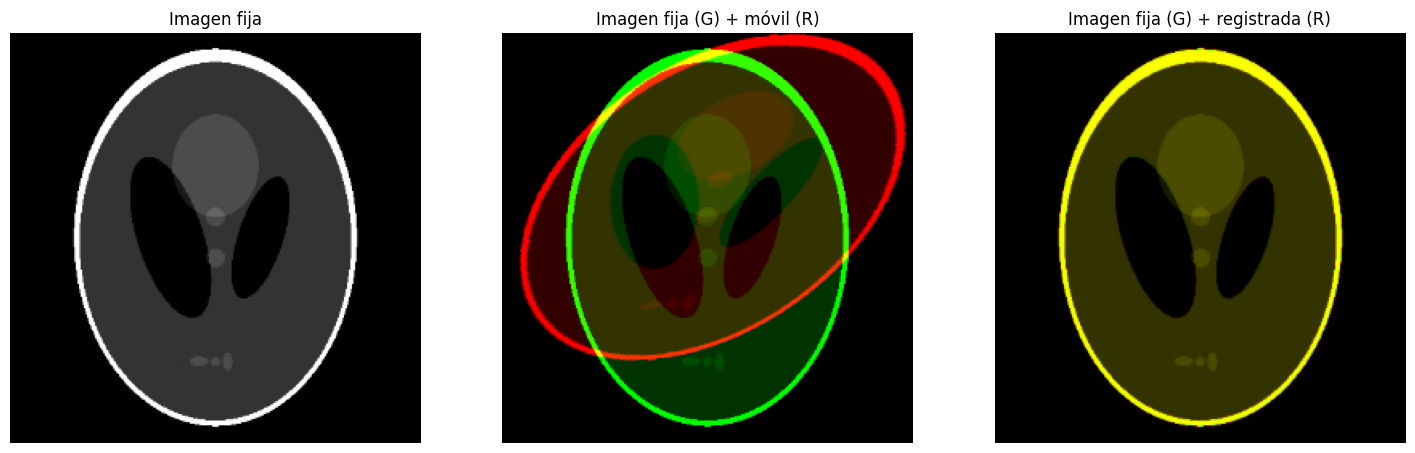

In [9]:
def register_affine_2d(fixed, moving, center):

    R = sitk.ImageRegistrationMethod()

    # Establecer métrica (SSD)
    R.SetMetricAsMeanSquares()

    # Parámetros del optimizador (Descenso por gradiente)
    R.SetOptimizerAsRegularStepGradientDescent(
        2.0,  # learningRate
        1e-4,  # minStep
        500,  # numberOfIterations
        0.5,  # relaxationFactor (cómo reduce el paso cuando cambia de dirección)
        1e-8,
    )  # gradientMagnitudeTolerance
    R.SetOptimizerScalesFromIndexShift()
    # Interpolador (lineal)
    R.SetInterpolator(sitk.sitkLinear)
    # Tipo de transformación e inicialización
    init = sitk.AffineTransform(2)
    init.SetCenter(center)
    R.SetInitialTransform(init)
    print("Parámetros iniciales de la transformación: ", init.GetParameters())

    # Opciones de multiresolución y suavizado (3 niveles)
    R.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    R.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])

    # Ejecución del algoritmo
    final = R.Execute(fixed, moving)

    print("-------")
    print("Optimizer stop condition: ", R.GetOptimizerStopConditionDescription())
    print("Iteration: ", R.GetOptimizerIteration())
    print("Metric value: ", R.GetMetricValue())
    print("-------")
    return final


t_affine = register_affine_2d(fixed, moving_aff, center)

# Aplicamos la transformación estimada sobre la imagen móvil
moved_aff = sitk.Resample(
    moving_aff, fixed, t_affine, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)

# Comparamos los parámetros estimados con los reales
print("COMPARACIÓN DE PARÁMETROS")
print(f"REAL:     {list(np.round(affine2D.GetParameters(), 4))}")
print(f"ESTIMADO: {list(np.round(t_affine.GetParameters(), 4))}")

# Visualización
plt.figure(figsize=(18, 6))

# Imagen fija
plt.subplot(1, 3, 1)
plt.imshow(If, cmap="gray")
plt.axis("off")
plt.title("Imagen fija")

# Imagen fija con imagen móvil superpuesta (pre-registro)
plt.subplot(1, 3, 2)
plt.imshow(overlay_rg(If, Im))
plt.axis("off")
plt.title("Imagen fija (G) + móvil (R)")

# Imagen fija con imagen registrada superpuesta
Ireg = sitk.GetArrayFromImage(moved_aff)
plt.subplot(1, 3, 3)
plt.imshow(overlay_rg(If, Ireg))
plt.axis("off")
plt.title("Imagen fija (G) + registrada (R)")

### *Transformación FFD (Free-Form Deformation) mediante B-splines*

La `BSplineTransform` en `SimpleITK` es el estándar para el registro no rígido (deformable). 

A diferencia de la transformación afín, permite que diferentes partes de la imagen se muevan en direcciones distintas para ajustar órganos que cambian de forma.

No usa una matriz global. Define una rejilla de puntos de control sobre la imagen. Al mover un punto de la rejilla, la imagen se deforma suavemente a su alrededor usando funciones base polinómicas (B-Splines).


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

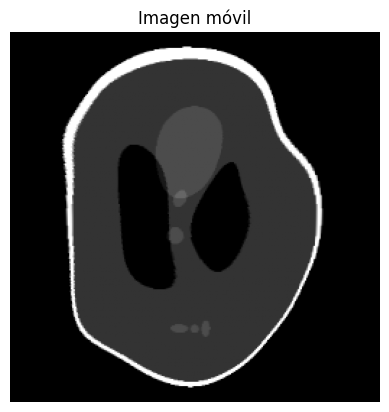

In [10]:
# Definimos la nueva transformación FFD

# 2. Inicializar la Transformación B-Spline (spline cúbico de orden 3)
# Definimos una rejilla de 8x8 puntos de control
mesh_size = [8, 8]
bspline = sitk.BSplineTransformInitializer(fixed, mesh_size)

# 3. Modificar los parámetros (Deformación manual)
# Una rejilla de 8x8 en 2D tiene: (8+3)*(8+3) * 2 = 121 parámetros
# (SimpleITK añade márgenes para asegurar la curvatura en los bordes)
params = list(bspline.GetParameters())

# Vamos a mover los parámetros centrales para ver una deformación clara
# Desplazamos la mitad de los puntos 30 unidades en X
for i in range(len(params) // 2):
    if i % 5 == 0:
        params[i] += 30.0

bspline.SetParameters(params)

# 4. Aplicar la deformación (Resample)
moving_ffd = sitk.Resample(
    fixed, fixed, bspline, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)

plt.imshow(sitk.GetArrayFromImage(moving_ffd), cmap="gray")
plt.title("Imagen móvil")
plt.axis("off")

Aplicamos registro afín y analizamos hasta dónde puede corregir el alineamiento.

Parámetros iniciales de la transformación:  (1.0, 0.0, 0.0, 1.0, 0.0, 0.0)
-------
Optimizer stop condition:  RegularStepGradientDescentOptimizerv4: Maximum number of iterations (500) exceeded.
Iteration:  500
Metric value:  0.029449479486468737
-------


Text(0.5, 1.0, 'Imagen fija (G) + registrada (R)')

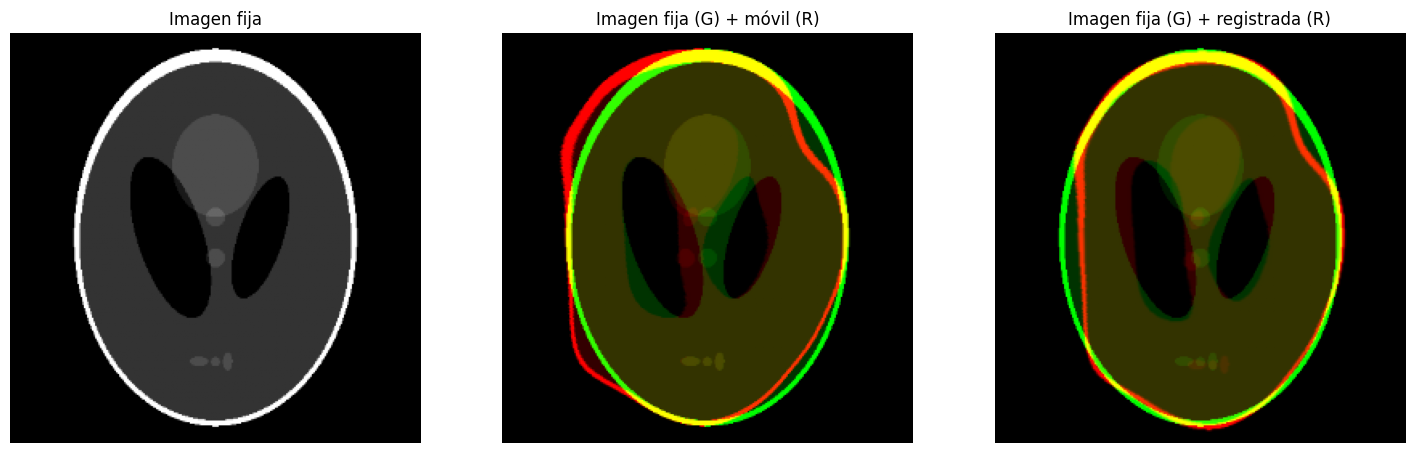

In [11]:
t_ffd_aff = register_affine_2d(fixed, moving_ffd, center)

# Aplicamos la transformación estimada sobre la imagen móvil
moved_ffd_aff = sitk.Resample(
    moving_ffd, fixed, t_ffd_aff, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)

# Visualización
plt.figure(figsize=(18, 6))

# Imagen fija
If = sitk.GetArrayFromImage(fixed)
plt.subplot(1, 3, 1)
plt.imshow(If, cmap="gray")
plt.axis("off")
plt.title("Imagen fija")

# Imagen fija con imagen móvil superpuesta (pre-registro)
Im = sitk.GetArrayFromImage(moving_ffd)
plt.subplot(1, 3, 2)
plt.imshow(overlay_rg(If, Im))
plt.axis("off")
plt.title("Imagen fija (G) + móvil (R)")

# Imagen fija con imagen registrada superpuesta
Ireg = sitk.GetArrayFromImage(moved_ffd_aff)
plt.subplot(1, 3, 3)
plt.imshow(overlay_rg(If, Ireg))
plt.axis("off")
plt.title("Imagen fija (G) + registrada (R)")

Ahora aplicamos un registro FFD con B-spline. El proceso es más exigente que con un registro afín. Necesitamos un optimizador más robusto (como LBFGS2).

In [12]:
def register_ffd_2d(fixed, moving, mesh_size):

    R = sitk.ImageRegistrationMethod()

    # Establecer métrica (SSD)
    R.SetMetricAsMeanSquares()

    # Parámetros del optimizador (LBFGS2, más eficiente que el descenso por gradiente para BSplines)
    R.SetOptimizerAsLBFGS2(
        solutionAccuracy=1e-7, numberOfIterations=100, deltaConvergenceTolerance=1e-9
    )
    # R.SetOptimizerScalesFromIndexShift();

    # Interpolador (lineal)
    R.SetInterpolator(sitk.sitkLinear)
    # Tipo de transformación e inicialización
    init = sitk.BSplineTransformInitializer(fixed, mesh_size)
    R.SetInitialTransform(init)
    # print("Parámetros iniciales de la transformación: ",init.GetParameters())

    # Opciones de multiresolución y suavizado (3 niveles)
    R.SetShrinkFactorsPerLevel(shrinkFactors=[4, 2, 1])
    R.SetSmoothingSigmasPerLevel(smoothingSigmas=[2, 1, 0])

    # Ejecución del algoritmo
    final = R.Execute(fixed, moving)

    print("-------")
    print("Optimizer stop condition: ", R.GetOptimizerStopConditionDescription())
    print("Iteration: ", R.GetOptimizerIteration())
    print("Metric value: ", R.GetMetricValue())
    print("-------")
    return final


-------
Optimizer stop condition:  Already minimized
Iteration:  28
Metric value:  0.0011465536894814561
-------


Text(0.5, 1.0, 'Imagen fija (G) + registrada (R)')

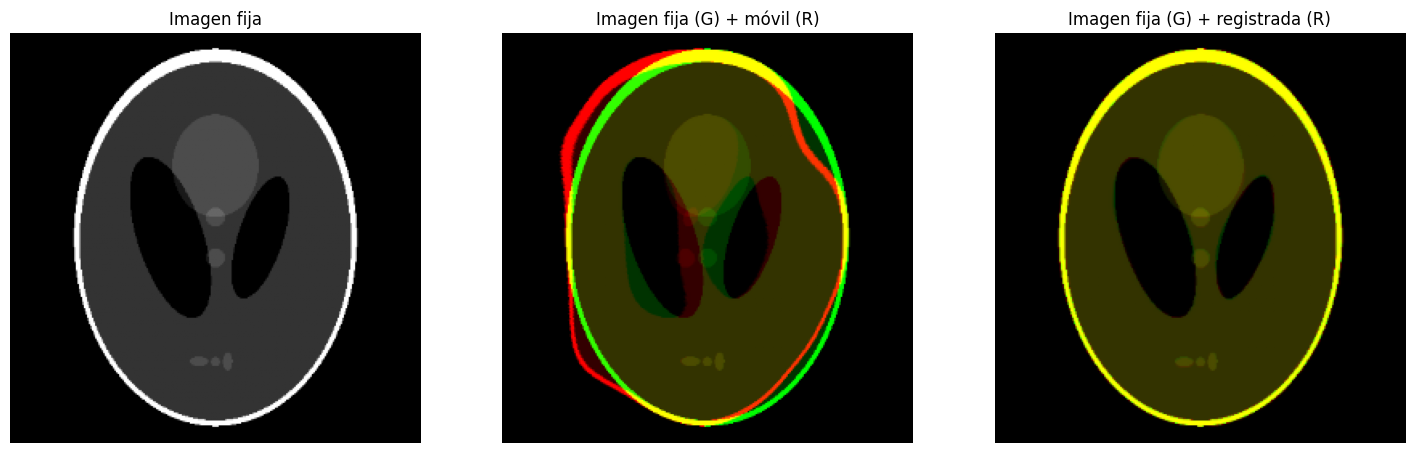

In [13]:
mesh_size = [8, 8]
t_ffd = register_ffd_2d(fixed, moving_ffd, mesh_size)

# Aplicamos la transformación estimada sobre la imagen móvil
moved_ffd = sitk.Resample(
    moving_ffd, fixed, t_ffd, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)

# Visualización
plt.figure(figsize=(18, 6))

# Imagen fija
If = sitk.GetArrayFromImage(fixed)
plt.subplot(1, 3, 1)
plt.imshow(If, cmap="gray")
plt.axis("off")
plt.title("Imagen fija")

# Imagen fija con imagen móvil superpuesta (pre-registro)
Im = sitk.GetArrayFromImage(moving_ffd)
plt.subplot(1, 3, 2)
plt.imshow(overlay_rg(If, Im))
plt.axis("off")
plt.title("Imagen fija (G) + móvil (R)")

# Imagen fija con imagen registrada superpuesta
Ireg = sitk.GetArrayFromImage(moved_ffd)
plt.subplot(1, 3, 3)
plt.imshow(overlay_rg(If, Ireg))
plt.axis("off")
plt.title("Imagen fija (G) + registrada (R)")

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='revision01'></a>

## <span style="color: #667eea;">2. Registro pair-wise monomodal (CT - CT)</span>

Esta sección se dedica al problema del registro monomodal sobre datos reales. En concreto, al alineamiento de imágenes CT abdominales.

### *2.1 Dataset: Abdomen CT–CT — Learn2Reg Challenge*

El dataset Abdomen CT–CT forma parte del conjunto de tareas del challenge internacional [Learn2Reg](https://learn2reg.grand-challenge.org/Datasets/) para evaluación de métodos de registro médico.

Breve descripción del dataset:

- Modalidad: Tomografía computarizada (CT) → CT (registro monomodal)

- Dominio: Pacientes diferentes (inter-patient)

- Dimensiones de imagen: volúmenes 3D

Para cada volumen se proporcionan etiquetas anatómicas de 13 órganos abdominales incluyendo: bazo (spleen), riñones derecho e izquierdo, vesícula biliar, esófago, hígado, estómago, aorta, vena cava inferior, venas portal y esplénica, páncreas y glándulas suprarrenales (izquierda y derecha). Estas anotaciones permiten evaluar la calidad del registro en términos anatómicos.

**Añadir el dataset:**

Como primer paso, añadimos el dataset a `/kaggle/input/`:

* Haz clic en **"+ Add Input"** (panel derecho), busca el dataset AbdomenCTCT y haz clic en el botón añadir (**"+"**).

A continuación, establecemos la ruta al dataset y al fichero JSON.

In [14]:
import os, json
from pathlib import Path

# Ruta al dataset (debe añadirse AbdomenCTCT previamente desde el panel "+ Add Input" marcando el tag " Datasets")
data_path = Path("./kaggle/input/datasets/mapraveenpf042201/abdomenctct/AbdomenCTCT")

# Ruta al fichero "AbdomenCTCT_dataset.json"
JSON_PATH = data_path / "AbdomenCTCT_dataset.json"

try:
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        ds = json.load(f)
except FileNotFoundError:
    print(f"¡Error! No encontré el archivo en: {JSON_PATH}")

### 2.2 Leer el fichero JSON y elegir un par de imágenes
El fichero `AbdomenCTCT_dataset.json` contiene:
- `registration_val`: lista de pares de imágenes fixed/moving
- `labels`: nombres de órganos (1..13)

Puedes cambiar `PAIR_INDEX` para probar distintos pares.

In [15]:
pairs = ds.get("registration_val", [])
if not pairs:
    raise RuntimeError("No encuentro 'registration_val' en el JSON.")

labels_map = ds["labels"]["0"]
label_ids = [int(k) for k in labels_map.keys() if int(k) != 0]

print("Num pares registration_val:", len(pairs))
print("Órganos:")
for k in range(1, 14):
    print(f"  {k:2d} {labels_map[str(k)]}")

PAIR_INDEX = 11  # prueba 0..len(pairs)-1
pair = pairs[PAIR_INDEX]

fixed_rel = pair["fixed"].replace("./", "")
moving_rel = pair["moving"].replace("./", "")

fixed_path = data_path / fixed_rel.replace(".gz", "")
fixed_lab_path = Path(str(fixed_path).replace("imagesTr", "labelsTr"))
fixed_path = fixed_path / os.listdir(fixed_path)[0]
fixed_lab_path = fixed_lab_path / os.listdir(fixed_lab_path)[0]

moving_path = data_path / moving_rel.replace(".gz", "")
moving_lab_path = Path(str(moving_path).replace("imagesTr", "labelsTr"))
moving_path = moving_path / os.listdir(moving_path)[0]
moving_lab_path = moving_lab_path / os.listdir(moving_lab_path)[0]

print("\nPar:", PAIR_INDEX)
print("Fixed :", fixed_path)
print("Moving:", moving_path)

for p in [fixed_path, moving_path, fixed_lab_path, moving_lab_path]:
    if not p.exists():
        raise FileNotFoundError(f"Falta: {p}")

Num pares registration_val: 45
Órganos:
   1 spleen
   2 right kidney
   3 left kidney
   4 gall bladder
   5 esophagus
   6 liver
   7 stomach
   8 aorta
   9 inferior vena cava
  10 portal and splenic vein
  11 pancreas
  12 left adrenal gland
  13 right adrenal gland

Par: 11
Fixed : kaggle/input/datasets/mapraveenpf042201/abdomenctct/AbdomenCTCT/imagesTr/AbdomenCTCT_0004_0000.nii/abdomen_ctct_0004_0000.nii
Moving: kaggle/input/datasets/mapraveenpf042201/abdomenctct/AbdomenCTCT/imagesTr/AbdomenCTCT_0013_0000.nii/abdomen_ctct_0013_0000.nii


### 2.3 Utilidades

A continuación, definimos algunas funciones que serán de utilidad en los siguientes apartados.

In [16]:
def sitk_to_np(img):
    return sitk.GetArrayViewFromImage(img)


def show_mid_slices(img, title=""):
    arr = sitk_to_np(img)  # z,y,x
    z, y, x = arr.shape[0] // 2, arr.shape[1] // 2, arr.shape[2] // 2
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1)
    plt.imshow(arr[z, :, :], cmap="gray")
    plt.title(f"{title} axial")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(arr[:, y, :], cmap="gray")
    plt.title(f"{title} coronal")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(arr[:, :, x], cmap="gray")
    plt.title(f"{title} sagittal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def dice_per_label(seg_fixed, seg_moved, label_ids):
    a = sitk_to_np(seg_fixed).astype(np.int32)
    b = sitk_to_np(seg_moved).astype(np.int32)
    out = {}
    for l in label_ids:
        aa = a == l
        bb = b == l
        inter = np.logical_and(aa, bb).sum()
        den = aa.sum() + bb.sum()
        out[l] = float((2.0 * inter) / (den + 1e-8))
    return out


def plot_dice(dice_dict, labels_map, title="Dice por órgano"):
    keys = sorted(dice_dict.keys())
    vals = [dice_dict[k] for k in keys]
    names = [labels_map[str(k)] for k in keys]

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(keys)), vals)
    plt.xticks(range(len(keys)), [f"{k}" for k in keys], rotation=0)
    plt.ylim(0, 1.0)
    plt.ylabel("Dice")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # Tabla ordenada (top/bottom)
    worst = sorted(dice_dict.items(), key=lambda x: x[1])[:5]
    best = sorted(dice_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    print("Top 5 mejores:")
    for k, v in best:
        print(f"  {k:2d} {labels_map[str(k)]:>22s}  Dice={v:.3f}")
    print("Top 5 peores:")
    for k, v in worst:
        print(f"  {k:2d} {labels_map[str(k)]:>22s}  Dice={v:.3f}")


def overlay_contours_on_slice(ct_img, seg_fixed, seg_moved, axis="axial", title=""):
    """Dibuja contornos de seg_fixed (verde) y seg_moved (rojo) sobre un corte medio del CT."""
    ct = sitk_to_np(ct_img)
    sf = sitk_to_np(seg_fixed).astype(np.int32)
    sm = sitk_to_np(seg_moved).astype(np.int32)

    if axis == "axial":
        idx = ct.shape[0] // 2
        ct2 = ct[idx, :, :]
        sf2 = sf[idx, :, :]
        sm2 = sm[idx, :, :]
    elif axis == "coronal":
        idx = ct.shape[1] // 2
        ct2 = ct[:, idx, :]
        sf2 = sf[:, idx, :]
        sm2 = sm[:, idx, :]
    else:  # sagittal
        idx = ct.shape[2] // 2
        ct2 = ct[:, :, idx]
        sf2 = sf[:, :, idx]
        sm2 = sm[:, :, idx]

    # contornos binarios (sobre todos los órganos a la vez)
    def contours(mask):
        # borde = mask XOR erosion(mask)
        m = (mask > 0).astype(np.uint8)
        # erosión simple con conv 3x3 (numpy) para no depender de skimage
        # Para robustez, usamos sitk para erosion 2D:
        img2 = sitk.GetImageFromArray(m.astype(np.uint8))
        er = sitk.BinaryErode(img2, (1, 1))
        er = sitk_to_np(er).astype(np.uint8)
        return (m ^ er).astype(bool)

    c_fixed = contours(sf2)
    c_moved = contours(sm2)

    plt.figure(figsize=(5, 5))
    plt.imshow(ct2, cmap="gray")
    plt.contour(c_fixed.astype(np.uint8), levels=[0.5], linewidths=1.0)  # default color
    # matplotlib default first contour is blue; set explicitly by plotting twice with colors via contour:
    plt.cla()
    plt.imshow(ct2, cmap="gray")
    plt.contour(c_fixed.astype(np.uint8), levels=[0.5], colors="lime", linewidths=1.0)
    plt.contour(c_moved.astype(np.uint8), levels=[0.5], colors="red", linewidths=1.0)
    plt.title(title + f" ({axis})\nverde=fixed label, rojo=moving warped")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def show_checkerboard_slice(
    fixed, moved, axis="axial", squares=8, title="checkerboard"
):
    # Extrae un corte medio, crea imágenes 2D y aplica CheckerBoard
    arr_f = sitk_to_np(fixed)
    arr_m = sitk_to_np(moved)
    if axis == "axial":
        idx = arr_f.shape[0] // 2
        f2 = arr_f[idx, :, :]
        m2 = arr_m[idx, :, :]
    elif axis == "coronal":
        idx = arr_f.shape[1] // 2
        f2 = arr_f[:, idx, :]
        m2 = arr_m[:, idx, :]
    else:
        idx = arr_f.shape[2] // 2
        f2 = arr_f[:, :, idx]
        m2 = arr_m[:, :, idx]

    f_img = sitk.GetImageFromArray(f2.astype(np.float32))
    m_img = sitk.GetImageFromArray(m2.astype(np.float32))
    cb = sitk.CheckerBoard(f_img, m_img, [squares, squares])
    plt.figure(figsize=(5, 5))
    plt.imshow(sitk_to_np(cb), cmap="gray")
    plt.title(f"{title} ({axis})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### 2.4 Preprocesado de las imágenes

- Los datos CT vienen en unidades HU; hacemos **clip** para limitar outliers y normalizamos a [0,1].
- Para que el registro sea rápido en CPU, hacemos **resample isotrópico** (2.5 mm).

Puedes jugar con `SPACING`: cuanto más pequeño, más detalle y más lento.

Fixed size: (154, 128, 205) spacing: (2.5, 2.5, 2.5)
Moving size: (154, 128, 205) spacing: (2.5, 2.5, 2.5)


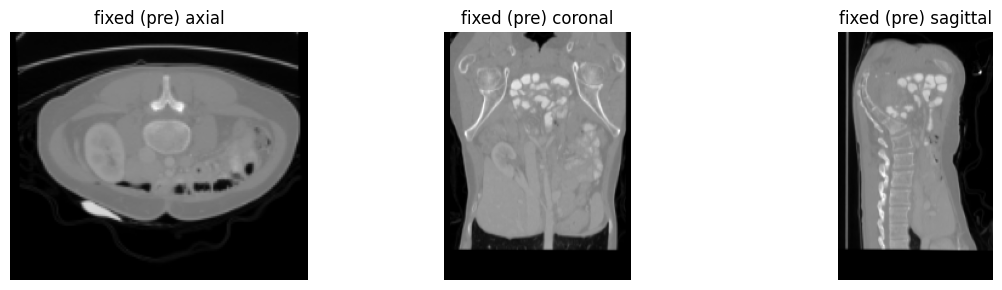

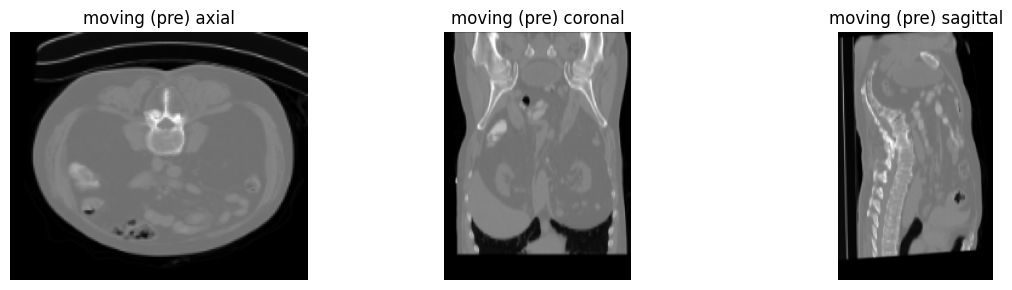

In [17]:
def read_img(path: Path):
    return sitk.Cast(sitk.ReadImage(str(path)), sitk.sitkFloat32)


def read_seg(path: Path):
    return sitk.Cast(sitk.ReadImage(str(path)), sitk.sitkUInt16)


def normalize_ct(img, clip=(-1000, 1000)):
    img = sitk.Clamp(img, sitk.sitkFloat32, clip[0], clip[1])
    img = sitk.ShiftScale(img, shift=-clip[0], scale=1.0 / (clip[1] - clip[0]))
    return img


def resample_isotropic(img, spacing=(2.5, 2.5, 2.5), interp=sitk.sitkLinear):
    orig_spacing = img.GetSpacing()
    orig_size = img.GetSize()
    new_size = [
        int(round(orig_size[i] * (orig_spacing[i] / spacing[i]))) for i in range(3)
    ]
    return sitk.Resample(
        img,
        new_size,
        sitk.Transform(),
        interp,
        img.GetOrigin(),
        spacing,
        img.GetDirection(),
        0.0,
        img.GetPixelID(),
    )


fixed = normalize_ct(read_img(fixed_path))
moving = normalize_ct(read_img(moving_path))
fixed_lab = read_seg(fixed_lab_path)
moving_lab = read_seg(moving_lab_path)

SPACING = (2.5, 2.5, 2.5)  # prueba (2.0,2.0,2.0) si tu CPU va sobrada
fixed_p = resample_isotropic(fixed, SPACING, sitk.sitkLinear)
moving_p = resample_isotropic(moving, SPACING, sitk.sitkLinear)
fixed_lab_p = resample_isotropic(fixed_lab, SPACING, sitk.sitkNearestNeighbor)
moving_lab_p = resample_isotropic(moving_lab, SPACING, sitk.sitkNearestNeighbor)

print("Fixed size:", fixed_p.GetSize(), "spacing:", fixed_p.GetSpacing())
print("Moving size:", moving_p.GetSize(), "spacing:", moving_p.GetSpacing())

show_mid_slices(fixed_p, "fixed (pre)")
show_mid_slices(moving_p, "moving (pre)")

### 2.5 Registro afín 3D (moving → fixed)

- **Transformación**: Afín 3D (12 DOF: 9 parámetros de la matriz afín + 3 parámetros de traslación).
- **Métrica**: Si bien la métrica clásica para registro monomodal es la SSD (Sum of Squared Differences), esta métrica asume una correspondencia directa de intensidades.
El dataset que estamos utilizando contiene imágenes de la misma modalidad (CT) pero inter-paciente. 
Por tanto, emplearemos Mutual Information (Nº de histogramas), que es útil en escenarios con diferencias de intensidad.
- **Optimizador**: RegularStepGradientDescent.
- **Multiresolución**: se utiliza para evitar mínimos locales y mejorar la convergencia. Aplicaremos los parámetros: shrink [4,2,1] y smoothing [2,1,0].

Al final, mostramos la imagen móvil `moving` transformada sobre la rejilla de `fixed`.

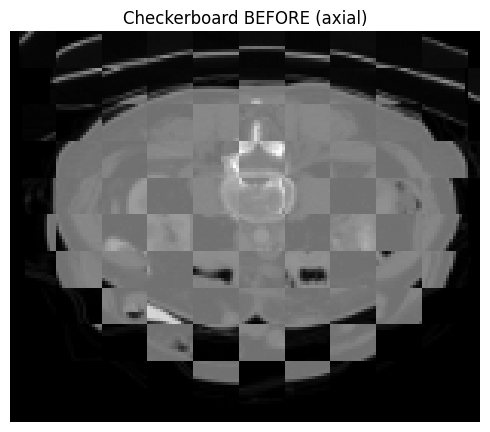

Metric final: -0.6050276472493367 | iters: 120


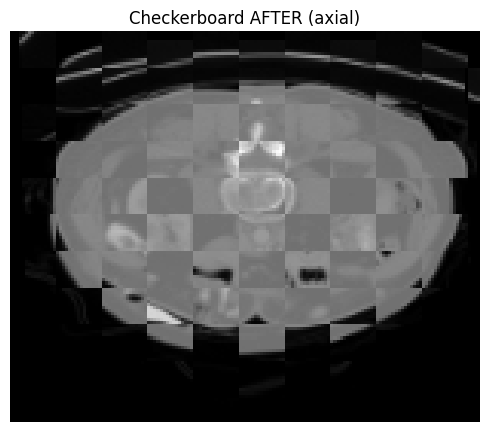

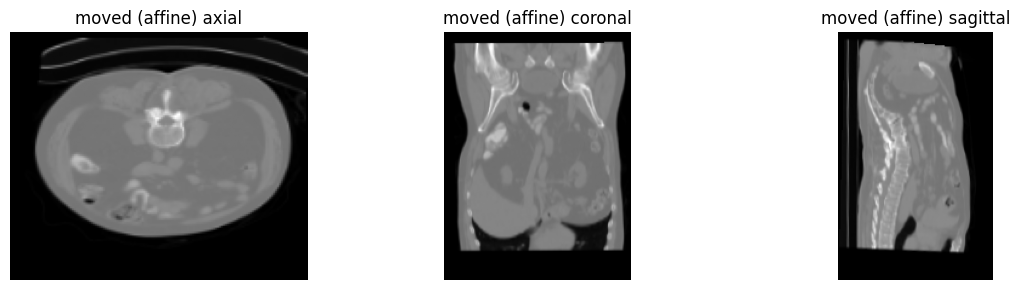

In [18]:
def register_affine_3d(fixed, moving, sampling=0.2, iters=120):
    # Crear método de registro
    R = sitk.ImageRegistrationMethod()

    # ----------------------------
    # MÉTRICA
    # ----------------------------
    # R.SetMetricAsMeanSquares()  # Sum of Squared Differences métrica clásica en registro monomodal (no es robusta ante variaciones de intensidad o registro multimodal)
    # R.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    R.SetMetricAsCorrelation()
    R.SetMetricSamplingStrategy(
        R.RANDOM
    )  # Elige puntos al azar para calcular la métrica
    R.SetMetricSamplingPercentage(
        sampling, seed=42
    )  # Define cuántos puntos se eligen para calcular la métrica, fijamos semilla para reproducibilidad del resultado

    # ----------------------------
    # INTERPOLADOR: Lineal (estándar por velocidad)
    # ----------------------------
    R.SetInterpolator(sitk.sitkLinear)

    # ----------------------------
    # OPTIMIZADOR: Descenso por gradiente
    # ----------------------------
    R.SetOptimizerAsRegularStepGradientDescent(
        learningRate=2.0,
        minStep=1e-4,
        numberOfIterations=iters,
        relaxationFactor=0.5,
        gradientMagnitudeTolerance=1e-8,
    )
    R.SetOptimizerScalesFromPhysicalShift()

    # ----------------------------
    # TRANSFORMACIÓN
    # ----------------------------
    init = sitk.CenteredTransformInitializer(
        fixed,
        moving,
        sitk.AffineTransform(3),
        sitk.CenteredTransformInitializerFilter.GEOMETRY,
    )
    R.SetInitialTransform(init)

    # ----------------------------
    # OPCIONES DE MULTIRESOLUCIÓN
    # ----------------------------
    R.SetShrinkFactorsPerLevel([4, 2, 1])
    R.SetSmoothingSigmasPerLevel([2, 1, 0])
    # R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # ----------------------------
    # EJECUCIÓN
    # ----------------------------
    final = R.Execute(fixed, moving)
    return final, R


# Baseline visual (antes)
show_checkerboard_slice(
    fixed_p, moving_p, axis="axial", squares=10, title="Checkerboard BEFORE"
)

T_aff, reg = register_affine_3d(fixed_p, moving_p, sampling=0.2, iters=120)
# Aplicación de la transformación sobre la imagen móvil
moved_aff = sitk.Resample(
    moving_p, fixed_p, T_aff, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)
# Aplicación de la transformación sobre la segmentación utilizando Nearest Neighbor como interpolador, porque son etiquetas discretas
moved_lab_aff = sitk.Resample(
    moving_lab_p, fixed_p, T_aff, sitk.sitkNearestNeighbor, 0, sitk.sitkUInt16
)

print("Metric final:", reg.GetMetricValue(), "| iters:", reg.GetOptimizerIteration())

# Visual de la imagen transformada (después)
show_checkerboard_slice(
    fixed_p, moved_aff, axis="axial", squares=10, title="Checkerboard AFTER"
)
show_mid_slices(moved_aff, "moved (affine)")

### 2.6 Comparación interactiva antes vs después (cortes)
Inspecciona **fixed / moving (antes) / moved (después)** con un slider y varios modos:
- **side-by-side** (3 paneles)
- **checkerboard** (fijo vs moving / fijo vs moved)
- **abs-diff** (|fixed−moving| vs |fixed−moved|)
- **overlay RG** (R=moving/moved, G=fixed)

In [ ]:
from ipywidgets import interact, IntSlider, Dropdown

# Requiere variables ya definidas en el notebook:
# fixed_p, moving_p, moved_aff
fixed_np = sitk.GetArrayFromImage(fixed_p).astype(np.float32)  # z,y,x
moving_np = sitk.GetArrayFromImage(moving_p).astype(np.float32)
moved_np = sitk.GetArrayFromImage(moved_aff).astype(np.float32)


def norm01(x):
    x = x - x.min()
    return x / (x.max() + 1e-8)


def get_slice(vol, axis, idx):
    if axis == "axial":
        return vol[idx, :, :]
    if axis == "coronal":
        return vol[:, idx, :]
    return vol[:, :, idx]  # sagittal


def checkerboard2d(a, b, squares=10):
    H, W = a.shape
    yy, xx = np.ogrid[:H, :W]
    tile_h = max(1, H // squares)
    tile_w = max(1, W // squares)
    mask = ((yy // tile_h + xx // tile_w) % 2).astype(bool)
    out = a.copy()
    out[mask] = b[mask]
    return out


def overlay_rg(a, b):
    a = norm01(a)
    b = norm01(b)
    rgb = np.stack([b, a, np.zeros_like(a)], axis=-1)  # R=b, G=a
    return np.clip(rgb, 0, 1)


max_ax = fixed_np.shape[0] - 1
max_co = fixed_np.shape[1] - 1
max_sa = fixed_np.shape[2] - 1


@interact(
    axis=Dropdown(
        options=["axial", "coronal", "sagittal"], value="axial", description="axis"
    ),
    idx=IntSlider(min=0, max=max_ax, step=1, value=max_ax // 2, description="slice"),
    mode=Dropdown(
        options=["side-by-side", "checkerboard", "abs-diff"],
        value="side-by-side",
        description="mode",
    ),
    squares=IntSlider(min=4, max=20, step=1, value=10, description="squares"),
)
def compare(axis="axial", idx=0, mode="side-by-side", squares=10):
    # cap idx to correct range for chosen axis
    if axis == "axial":
        idx = min(idx, max_ax)
    elif axis == "coronal":
        idx = min(idx, max_co)
    else:
        idx = min(idx, max_sa)

    f = get_slice(fixed_np, axis, idx)
    m = get_slice(moving_np, axis, idx)
    w = get_slice(moved_np, axis, idx)

    f1, m1, w1 = norm01(f), norm01(m), norm01(w)

    plt.figure(figsize=(12, 4))
    if mode == "side-by-side":
        plt.subplot(1, 3, 1)
        plt.imshow(f1, cmap="gray")
        plt.title("fixed")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(m1, cmap="gray")
        plt.title("moving (antes)")
        plt.axis("off")
        plt.subplot(1, 3, 3)
        plt.imshow(w1, cmap="gray")
        plt.title("moved (después)")
        plt.axis("off")
    elif mode == "checkerboard":
        cb_before = checkerboard2d(f1, m1, squares=squares)
        cb_after = checkerboard2d(f1, w1, squares=squares)
        plt.subplot(1, 2, 1)
        plt.imshow(cb_before, cmap="gray")
        plt.title("fixed vs moving")
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(cb_after, cmap="gray")
        plt.title("fixed vs moved")
        plt.axis("off")
    else:
        d_before = np.abs(f1 - m1)
        d_after = np.abs(f1 - w1)
        plt.subplot(1, 2, 1)
        plt.imshow(d_before, cmap="magma")
        plt.title("|fixed - moving|")
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(d_after, cmap="magma")
        plt.title("|fixed - moved|")
        plt.axis("off")

    plt.suptitle(f"{axis} slice={idx} | modo={mode}")
    plt.tight_layout()
    plt.show()


@interact(
    axis=Dropdown(
        options=["axial", "coronal", "sagittal"], value="axial", description="axis"
    ),
    idx=IntSlider(min=0, max=max_ax, step=1, value=max_ax // 2, description="slice"),
)
def compare_overlay(axis="axial", idx=0):
    if axis == "axial":
        idx = min(idx, max_ax)
    elif axis == "coronal":
        idx = min(idx, max_co)
    else:
        idx = min(idx, max_sa)

    f = get_slice(fixed_np, axis, idx)
    m = get_slice(moving_np, axis, idx)
    w = get_slice(moved_np, axis, idx)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(overlay_rg(f, m))
    plt.title("ANTES (R=moving, G=fixed)")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(overlay_rg(f, w))
    plt.title("DESPUÉS (R=moved, G=fixed)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='axis', options=('axial', 'coronal', 'sagittal'), value='axial'), I…

interactive(children=(Dropdown(description='axis', options=('axial', 'coronal', 'sagittal'), value='axial'), I…

### 2.7 Evaluación cuantitativa del registro: Coeficiente Dice por órgano
Para evaluar de forma cuantitativa el resultado del registro, utilizaremos las etiquetas de segmentación y calcularemos el [Coeficiente Dice](https://metrics-reloaded.dkfz.de/metric-library/dsc), que mide el solapamiento entre dos estructuras.

$DICE(A,B)= \frac{2|A\cap B|}{|A|+|B|}$

Esta métrica está definida en el intervalo [0,1]:
- 1.0: solapamiento perfecto
- 0.0: sin solapamiento

A continuación, mostramos utilizando las funciones `dice_per_label` y `plot_dice` definidas en el apartado Utilidades:
1. Media del coeficiente Dice sobre los diferentes órganos (labesls 1..13)
2. Diagrama de barras
3. Top-5 de mejores y peores órganos

Mean Dice (1..13): 0.1733560207053819


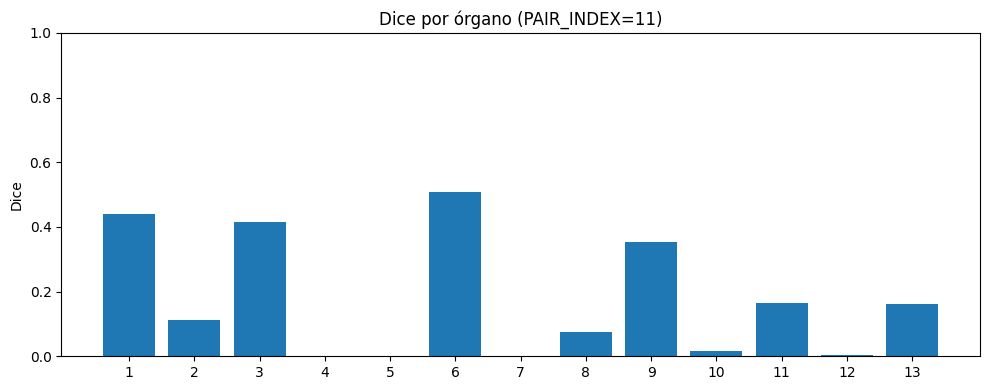

Top 5 mejores:
   6                  liver  Dice=0.509
   1                 spleen  Dice=0.439
   3            left kidney  Dice=0.416
   9     inferior vena cava  Dice=0.353
  11               pancreas  Dice=0.166
Top 5 peores:
   4           gall bladder  Dice=0.000
   5              esophagus  Dice=0.000
   7                stomach  Dice=0.001
  12     left adrenal gland  Dice=0.004
  10 portal and splenic vein  Dice=0.016


In [20]:
d = dice_per_label(fixed_lab_p, moved_lab_aff, label_ids)
mean_dice = float(np.mean(list(d.values())))
print("Mean Dice (1..13):", mean_dice)

plot_dice(d, labels_map, title=f"Dice por órgano (PAIR_INDEX={PAIR_INDEX})")

### 2.8 Evaluación visual: contornos de segmentación sobre CT
Aquí se ve *dónde* falla: contorno verde = label fija; rojo = label moving tras registro. Utilizamos la función `overlay_contours_on_slice`.

Si las curvas se solapan, el órgano está bien registrado; si hay separación, ahí está el error.

Text(0.5, 1.0, 'Imagen fija + moved lab (después)')

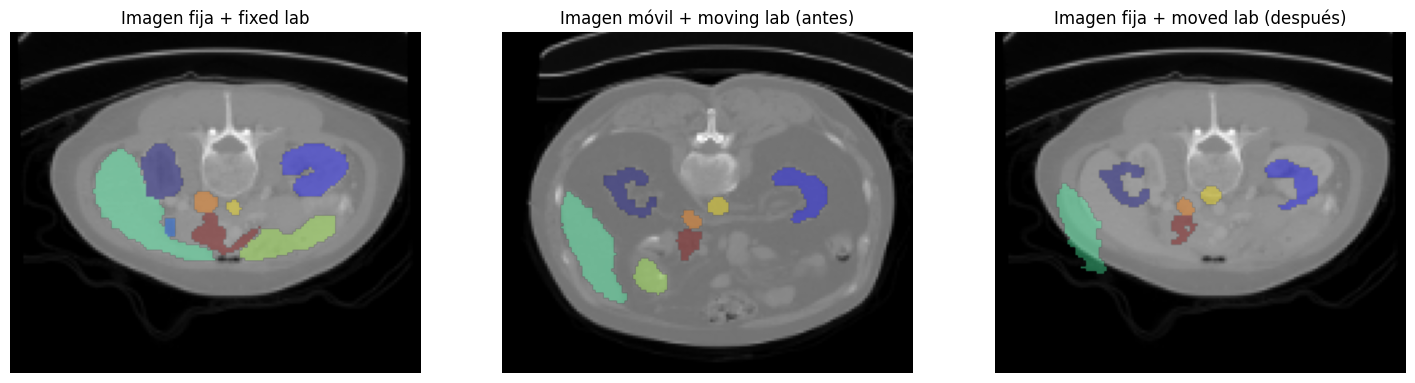

In [21]:
slice_idx = 120

plt.figure(figsize=(18, 6))

# Imagen fija con su segmentación superpuesta
If = sitk_to_np(fixed_p)
Lf = sitk_to_np(fixed_lab_p)
mask_f = np.ma.masked_where(Lf[slice_idx, :, :] == 0, Lf[slice_idx, :, :])
plt.subplot(1, 3, 1)
plt.imshow(If[slice_idx, :, :], cmap="gray")
plt.imshow(mask_f, cmap="jet", alpha=0.4)  # transparencia
plt.axis("off")
plt.title("Imagen fija + fixed lab")

# Imagen fija con etiquetas de la imagen móvil (antes) superpuesta
Im = sitk_to_np(moving_p)
Lm = sitk_to_np(moving_lab_p)
mask_m = np.ma.masked_where(Lm[slice_idx, :, :] == 0, Lm[slice_idx, :, :])
plt.subplot(1, 3, 2)
plt.imshow(Im[slice_idx, :, :], cmap="gray")
plt.imshow(mask_m, cmap="jet", alpha=0.4)  # transparencia
plt.axis("off")
plt.title("Imagen móvil + moving lab (antes)")

# Imagen fija con etiquetas de la imagen móvil (después) superpuesta
Lm_aff = sitk_to_np(moved_lab_aff)
mask_m_aff = np.ma.masked_where(Lm_aff[slice_idx, :, :] == 0, Lm_aff[slice_idx, :, :])
plt.subplot(1, 3, 3)
plt.imshow(If[slice_idx, :, :], cmap="gray")
plt.imshow(mask_m_aff, cmap="jet", alpha=0.4)  # transparencia
plt.axis("off")
plt.title("Imagen fija + moved lab (después)")

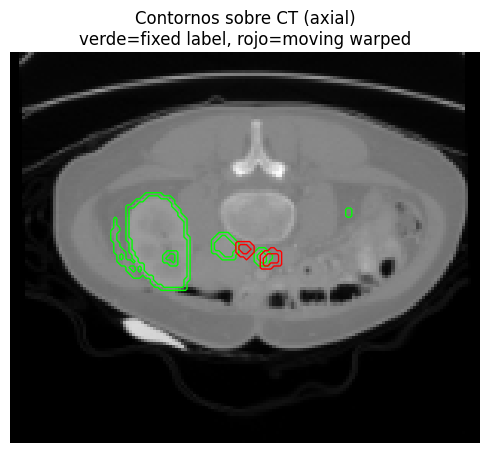

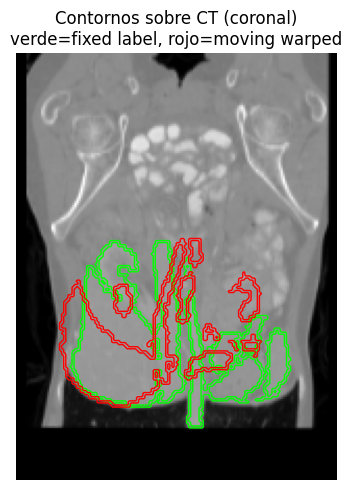

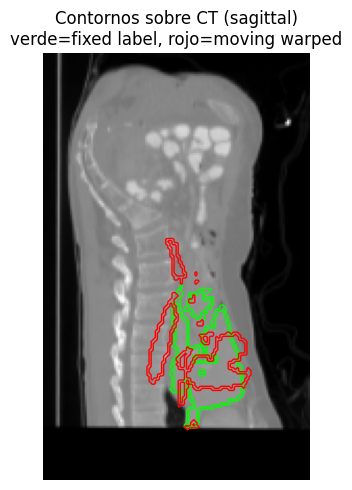

In [22]:
overlay_contours_on_slice(
    fixed_p, fixed_lab_p, moved_lab_aff, axis="axial", title="Contornos sobre CT"
)
overlay_contours_on_slice(
    fixed_p, fixed_lab_p, moved_lab_aff, axis="coronal", title="Contornos sobre CT"
)
overlay_contours_on_slice(
    fixed_p, fixed_lab_p, moved_lab_aff, axis="sagittal", title="Contornos sobre CT"
)

### 2.9 Retos para completar la sesión (elige 1–2 de las siguientes propuestas)
1) Cambia `SPACING` a (2.0,2.0,2.0). ¿Mejora Dice? ¿Cuánto se ralentiza?
2) Explora diferentes pares de imágenes, modificando `PAIR_INDEX`. ¿Qué pares son más difíciles y por qué?
3) Cambia el sampling de MI (`sampling=0.1` vs `0.3`). Analiza la estabilidad y el tiempo.
4) Sustituye MI por MeanSquares y compara (en inter-paciente suele empeorar).
5) (Si tienes tiempo) añade un refinamiento BSpline (deformable) sobre la afín.

PASO 1: Registro afín 3D (ya disponible como T_aff)

PASO 2: Refinamiento BSpline deformable...
-------
Stop condition: LBFGSBOptimizerv4: Function tolerance reached after 94 iterations. The relative reduction of the cost function <= 2.22045e-09 = CostFunctionConvergenceFactor (1e+07) * machine precision (2.22045e-16).
Iterations: 94
Metric value: -0.8603590261769661
-------

Resumen Dice (mean):
  Afín:    0.1734
  BSpline: 0.1008  (Δ = -0.0725)


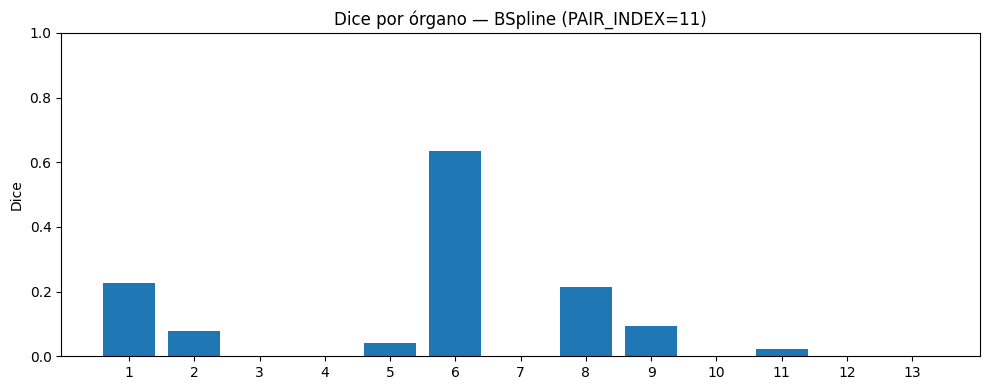

Top 5 mejores:
   6                  liver  Dice=0.635
   1                 spleen  Dice=0.227
   8                  aorta  Dice=0.215
   9     inferior vena cava  Dice=0.093
   2           right kidney  Dice=0.078
Top 5 peores:
   3            left kidney  Dice=0.000
   4           gall bladder  Dice=0.000
   7                stomach  Dice=0.000
  10 portal and splenic vein  Dice=0.000
  12     left adrenal gland  Dice=0.000


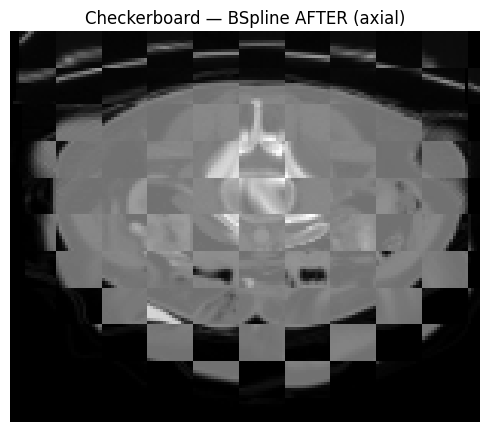

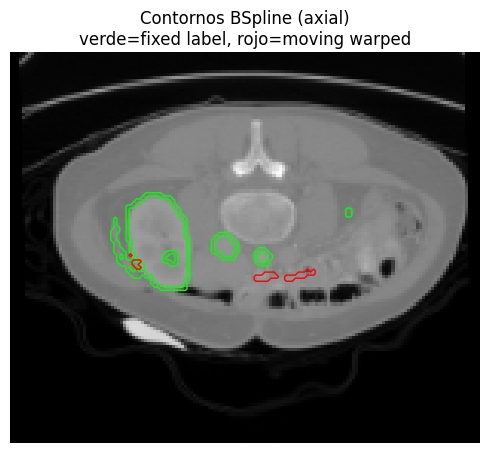

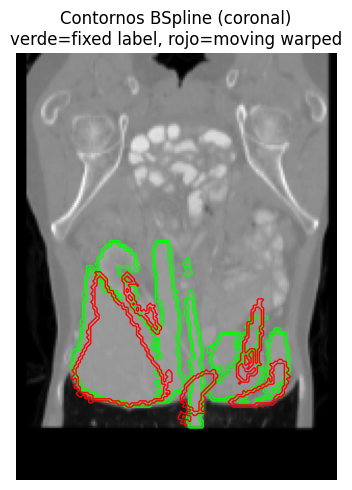

In [23]:
# ============================================================
# RETO 5: Refinamiento BSpline (deformable) sobre la afín
# ============================================================


def register_bspline_3d(
    fixed, moving, init_transform=None, mesh_size=[8, 8, 8], iters=100
):
    """
    Registro deformable BSpline 3D sobre una transformación inicial (p.ej. afín).
    """
    R = sitk.ImageRegistrationMethod()

    # Métrica: MI de Mattes (robusta en inter-paciente)
    R.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    R.SetMetricSamplingStrategy(R.RANDOM)
    R.SetMetricSamplingPercentage(0.1, seed=42)

    # Interpolador
    R.SetInterpolator(sitk.sitkLinear)

    # Optimizador LBFGSB (recomendado para BSpline, más eficiente que GD)
    R.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-5,
        numberOfIterations=iters,
        maximumNumberOfCorrections=5,
        maximumNumberOfFunctionEvaluations=1000,
        costFunctionConvergenceFactor=1e7,
    )

    # Transformación: BSpline inicializada sobre la rejilla de la imagen fija
    bspline_init = sitk.BSplineTransformInitializer(
        image1=fixed, transformDomainMeshSize=mesh_size, order=3
    )

    # Componer: afín (inicial) + BSpline (deformable)
    if init_transform is not None:
        composite = sitk.CompositeTransform(3)
        composite.AddTransform(init_transform)
        composite.AddTransform(bspline_init)
        R.SetInitialTransformAsBSpline(bspline_init, inPlace=True)
        # Aplicar la afín como "moving initial transform"
        R.SetMovingInitialTransform(init_transform)
    else:
        R.SetInitialTransformAsBSpline(bspline_init, inPlace=True)

    # Multiresolución (3 niveles)
    R.SetShrinkFactorsPerLevel([4, 2, 1])
    R.SetSmoothingSigmasPerLevel([2, 1, 0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    final = R.Execute(fixed, moving)

    print("-------")
    print("Stop condition:", R.GetOptimizerStopConditionDescription())
    print("Iterations:", R.GetOptimizerIteration())
    print("Metric value:", R.GetMetricValue())
    print("-------")

    return final, R


# --- Pipeline completo: Afín → BSpline ---

# Paso 1: Registro afín (ya ejecutado previamente como T_aff)
print("=" * 50)
print("PASO 1: Registro afín 3D (ya disponible como T_aff)")
print("=" * 50)

# Paso 2: Refinamiento BSpline sobre la afín
print("\nPASO 2: Refinamiento BSpline deformable...")
MESH_SIZE = [8, 8, 8]
T_bsp, reg_bsp = register_bspline_3d(
    fixed_p, moving_p, init_transform=T_aff, mesh_size=MESH_SIZE, iters=100
)

# Aplicar transformación compuesta sobre imagen e imagen de segmentación
moved_bsp = sitk.Resample(
    moving_p, fixed_p, T_bsp, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)
moved_lab_bsp = sitk.Resample(
    moving_lab_p, fixed_p, T_bsp, sitk.sitkNearestNeighbor, 0, sitk.sitkUInt16
)

# --- Evaluación cuantitativa ---
d_bsp = dice_per_label(fixed_lab_p, moved_lab_bsp, label_ids)
mean_bsp = float(np.mean(list(d_bsp.values())))

# Comparar Dice: antes / afín / BSpline
d_aff_eval = dice_per_label(fixed_lab_p, moved_lab_aff, label_ids)
mean_aff = float(np.mean(list(d_aff_eval.values())))

print("\nResumen Dice (mean):")
print(f"  Afín:    {mean_aff:.4f}")
print(f"  BSpline: {mean_bsp:.4f}  (Δ = {mean_bsp - mean_aff:+.4f})")

plot_dice(
    d_bsp, labels_map, title=f"Dice por órgano — BSpline (PAIR_INDEX={PAIR_INDEX})"
)

# --- Comparación visual ---
show_checkerboard_slice(
    fixed_p, moved_bsp, axis="axial", squares=10, title="Checkerboard — BSpline AFTER"
)
overlay_contours_on_slice(
    fixed_p, fixed_lab_p, moved_lab_bsp, axis="axial", title="Contornos BSpline"
)
overlay_contours_on_slice(
    fixed_p, fixed_lab_p, moved_lab_bsp, axis="coronal", title="Contornos BSpline"
)

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='revision01'></a>

## <span style="color: #667eea;">3. Registro pair-wise multimodal (MR - CT)</span>

Esta sección se dedica al problema del registro multimodal sobre datos reales. 

### *3.1 Dataset: Abdomen MR–CT — Learn2Reg Challenge*

El dataset Abdomen MR–CT también forma parte del conjunto de tareas del challenge internacional [Learn2Reg](https://learn2reg.grand-challenge.org/Datasets/).
Está diseñado para el registro multimodal intra-paciente de órganos abdominales.

- Objetivo: Alinear imágenes de tomografía computarizada (CT) y resonancia magnética (MRI) del mismo paciente, lo cual es crítico para diagnóstico y seguimiento clínico.
- Anotaciones: Incluye segmentaciones manuales de órganos (como hígado, bazo, riñones y páncreas) que sirven como "ground truth" para evaluar la precisión del registro mediante el coeficiente Dice o la distancia de Hausdorff.


**Añadir el dataset:**

* Haz clic en **"+ Add Input"** (panel derecho), busca el dataset AbdomenMRCT y haz clic en el botón añadir (**"+"**).

A continuación, establecemos la ruta al dataset y al fichero JSON. Seguidamente, elegimos un par de imágenes a registrar del conjunto de test.

In [24]:
import os, json
from pathlib import Path

# Ruta al dataset (debe añadirse AbdomenMRCT previamente desde el panel "+ Add Input" marcando el tag " Datasets")
data_path = Path("./kaggle/input/datasets/mapraveenpf042201/abdomenmrct/AbdomenMRCT")

# Ruta al fichero "AbdomenCTCT_dataset.json"
JSON_PATH = data_path / "AbdomenMRCT_dataset.json"

try:
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        ds = json.load(f)
except FileNotFoundError:
    print(f"¡Error! No encontré el archivo en: {JSON_PATH}")

pairs = ds.get("registration_val", [])
if not pairs:
    raise RuntimeError("No encuentro 'registration_val' en el JSON.")

print("Task:", ds["name"], "| pairings:", ds.get("pairings"))
print("Fixed modality:", ds["modality"]["0"], "| Moving modality:", ds["modality"]["1"])

labels_map = ds["labels"]["0"]
label_ids = [1, 2, 3, 4]
print("Órganos:")
for k in label_ids:
    print(f"  {k}: {labels_map[str(k)]}")

USE_SPLIT = "registration_test"  # "registration_val" o "registration_test"
pairs = ds[USE_SPLIT]
print("Num pares en", USE_SPLIT, ":", len(pairs))

PAIR_INDEX = 1
pair = pairs[PAIR_INDEX]

fixed_rel = pair["fixed"].replace("./", "")
moving_rel = pair["moving"].replace("./", "")

fixed_path = data_path / fixed_rel.replace(".gz", "")
fixed_lab_path = Path(str(fixed_path).replace("imagesTr", "labelsTr"))
fixed_mask_path = Path(str(fixed_path).replace("images", "masks"))
fixed_path = fixed_path / os.listdir(fixed_path)[0]
fixed_lab_path = fixed_lab_path / os.listdir(fixed_lab_path)[0]
fixed_mask_path = fixed_mask_path / os.listdir(fixed_mask_path)[0]

moving_path = data_path / moving_rel.replace(".gz", "")
moving_lab_path = Path(str(moving_path).replace("imagesTr", "labelsTr"))
moving_mask_path = Path(str(moving_path).replace("images", "masks"))
moving_path = moving_path / os.listdir(moving_path)[0]
moving_lab_path = moving_lab_path / os.listdir(moving_lab_path)[0]
moving_mask_path = moving_mask_path / os.listdir(moving_mask_path)[0]

print("\nPar:", PAIR_INDEX)
print("Fixed :", fixed_path)
print("Moving:", moving_path)

for p in [
    fixed_path,
    moving_path,
    fixed_lab_path,
    moving_lab_path,
    fixed_mask_path,
    moving_mask_path,
]:
    if not p.exists():
        raise FileNotFoundError(f"Falta: {p}")

Task: AbdomenMRCT | pairings: hybrid
Fixed modality: MR T1w | Moving modality: CT
Órganos:
  1: liver
  2: spleen
  3: right kidney
  4: left kidney
Num pares en registration_test : 8

Par: 1
Fixed : kaggle/input/datasets/mapraveenpf042201/abdomenmrct/AbdomenMRCT/imagesTs/AbdomenMRCT_0010_0000.nii/abdomen_mrct_tcia_mr_0010_0000.nii
Moving: kaggle/input/datasets/mapraveenpf042201/abdomenmrct/AbdomenMRCT/imagesTs/AbdomenMRCT_0010_0001.nii/abdomen_mrct_tcia_ct_0010_0000.nii


### *3.2 Utilidades*

In [25]:
def norm01_np(x):
    x = x.astype(np.float32)
    x = x - np.percentile(x, 1)
    x = x / (np.percentile(x, 99) + 1e-8)
    return np.clip(x, 0, 1)


def show_triplet_slices(fixed, moving, moved, title=""):
    f = sitk_to_np(fixed)
    m = sitk_to_np(moving)
    w = sitk_to_np(moved)
    z = f.shape[0] // 2
    f2, m2, w2 = norm01_np(f[z]), norm01_np(m[z]), norm01_np(w[z])
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(f2, cmap="gray")
    plt.title("fixed (MR)")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(m2, cmap="gray")
    plt.title("moving (CT) antes")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(w2, cmap="gray")
    plt.title("moving (CT) después")
    plt.axis("off")
    plt.suptitle(title + f" | axial z={z}")
    plt.tight_layout()
    plt.show()


def checkerboard2d(a, b, squares=10):
    H, W = a.shape
    yy, xx = np.ogrid[:H, :W]
    tile_h = max(1, H // squares)
    tile_w = max(1, W // squares)
    mask = ((yy // tile_h + xx // tile_w) % 2).astype(bool)
    out = a.copy()
    out[mask] = b[mask]
    return out


def show_checkerboard(fixed, other, axis="axial", squares=10, title=""):
    f = sitk_to_np(fixed)
    o = sitk_to_np(other)
    if axis == "axial":
        idx = f.shape[0] // 2
        f2, o2 = norm01_np(f[idx]), norm01_np(o[idx])
    elif axis == "coronal":
        idx = f.shape[1] // 2
        f2, o2 = norm01_np(f[:, idx, :]), norm01_np(o[:, idx, :])
    else:
        idx = f.shape[2] // 2
        f2, o2 = norm01_np(f[:, :, idx]), norm01_np(o[:, :, idx])
    cb = checkerboard2d(f2, o2, squares=squares)
    plt.figure(figsize=(5, 5))
    plt.imshow(cb, cmap="gray")
    plt.title(f"{title} ({axis})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def overlay_edges_on_fixed(fixed, other, axis="axial", title=""):
    """Para multimodal: compara bordes. Verde=bordes fixed (MR), rojo=bordes other (CT)."""
    f = sitk_to_np(fixed)
    o = sitk_to_np(other)
    if axis == "axial":
        idx = f.shape[0] // 2
        f2, o2 = f[idx], o[idx]
    elif axis == "coronal":
        idx = f.shape[1] // 2
        f2, o2 = f[:, idx, :], o[:, idx, :]
    else:
        idx = f.shape[2] // 2
        f2, o2 = f[:, :, idx], o[:, :, idx]

    def gradmag(im):
        im = norm01_np(im)
        gx = np.diff(im, axis=1, append=im[:, -1:])
        gy = np.diff(im, axis=0, append=im[-1:, :])
        return np.sqrt(gx * gx + gy * gy)

    ef = gradmag(f2)
    eo = gradmag(o2)

    rgb = np.stack([eo, ef, np.zeros_like(ef)], axis=-1)  # R=other edges, G=fixed edges
    rgb = np.clip(rgb / (np.percentile(rgb, 99) + 1e-8), 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.title(title + f" ({axis})\nR=bordes CT, G=bordes MR")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def dice_per_label(seg_fixed, seg_moved, label_ids):
    a = sitk_to_np(seg_fixed).astype(np.int32)
    b = sitk_to_np(seg_moved).astype(np.int32)
    out = {}
    for l in label_ids:
        aa = a == l
        bb = b == l
        inter = np.logical_and(aa, bb).sum()
        den = aa.sum() + bb.sum()
        out[l] = float((2.0 * inter) / (den + 1e-8))
    return out


def plot_dice(dice_dict, labels_map, title="Dice por órgano"):
    keys = sorted(dice_dict.keys())
    vals = [dice_dict[k] for k in keys]
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(keys)), vals)
    plt.xticks(
        range(len(keys)),
        [f"{k}:{labels_map[str(k)]}" for k in keys],
        rotation=25,
        ha="right",
    )
    plt.ylim(0, 1.0)
    plt.ylabel("Dice")
    plt.title(title)
    plt.tight_layout()
    plt.show()


### *3.2 Preprocesado multimodal*
**MR (T1w)**: Normalizamos con percentiles (robusto) → [0,1].

**CT** Clip HU [-1000, 1000] y normalización → [0,1].

**Resample**: Spacing isotrópico para acelerar.

Fixed size: (154, 128, 154) spacing: (2.5, 2.5, 2.5)
Moving size: (154, 128, 154) spacing: (2.5, 2.5, 2.5)


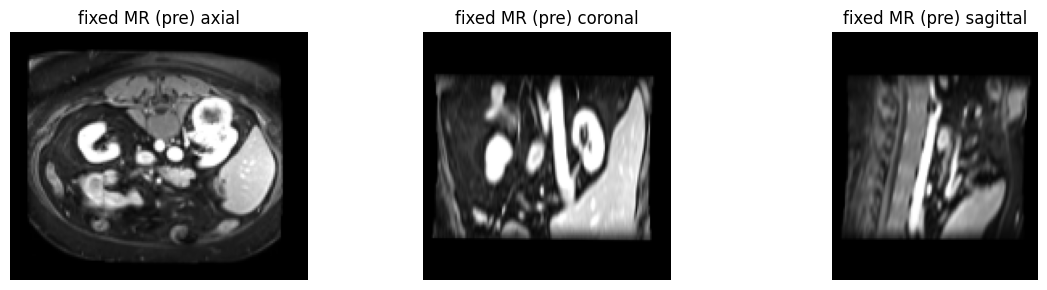

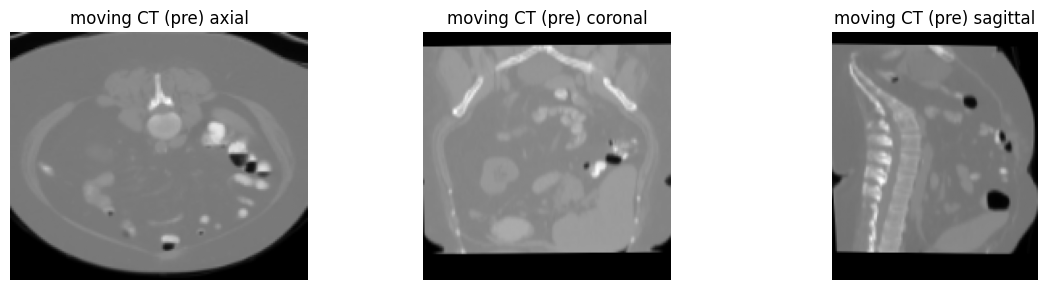

In [26]:
def read_img(path: Path):
    return sitk.Cast(sitk.ReadImage(str(path)), sitk.sitkFloat32)


def read_seg(path: Path):
    return sitk.Cast(sitk.ReadImage(str(path)), sitk.sitkUInt16)


def read_mask(path: Path):
    m = sitk.ReadImage(str(path))
    return sitk.Cast(m > 0, sitk.sitkUInt8)


def normalize_ct_hu(img, clip=(-1000, 1000)):
    img = sitk.Clamp(img, sitk.sitkFloat32, clip[0], clip[1])
    img = sitk.ShiftScale(img, shift=-clip[0], scale=1.0 / (clip[1] - clip[0]))
    return img


def normalize_mr_percentile(img, p_low=1, p_high=99):
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    lo, hi = np.percentile(arr, p_low), np.percentile(arr, p_high)
    arr = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)
    out = sitk.GetImageFromArray(arr)
    out.CopyInformation(img)
    return sitk.Cast(out, sitk.sitkFloat32)


def resample_isotropic(
    img, spacing=(2.5, 2.5, 2.5), interp=sitk.sitkLinear, default_value=0.0
):
    orig_spacing = img.GetSpacing()
    orig_size = img.GetSize()
    new_size = [
        int(round(orig_size[i] * (orig_spacing[i] / spacing[i]))) for i in range(3)
    ]
    return sitk.Resample(
        img,
        new_size,
        sitk.Transform(),
        interp,
        img.GetOrigin(),
        spacing,
        img.GetDirection(),
        default_value,
        img.GetPixelID(),
    )


fixed_mr = read_img(fixed_path)
moving_ct = read_img(moving_path)
fixed_lab = read_seg(fixed_lab_path)
moving_lab = read_seg(moving_lab_path)
fixed_mask = read_mask(fixed_mask_path)
moving_mask = read_mask(moving_mask_path)

fixed_mr_n = normalize_mr_percentile(fixed_mr)
moving_ct_n = normalize_ct_hu(moving_ct)

SPACING = (2.5, 2.5, 2.5)
fixed_p = resample_isotropic(fixed_mr_n, SPACING, sitk.sitkLinear, 0.0)
moving_p = resample_isotropic(moving_ct_n, SPACING, sitk.sitkLinear, 0.0)

fixed_lab_p = resample_isotropic(fixed_lab, SPACING, sitk.sitkNearestNeighbor, 0)
moving_lab_p = resample_isotropic(moving_lab, SPACING, sitk.sitkNearestNeighbor, 0)

fixed_mask_p = resample_isotropic(fixed_mask, SPACING, sitk.sitkNearestNeighbor, 0)
moving_mask_p = resample_isotropic(moving_mask, SPACING, sitk.sitkNearestNeighbor, 0)

print("Fixed size:", fixed_p.GetSize(), "spacing:", fixed_p.GetSpacing())
print("Moving size:", moving_p.GetSize(), "spacing:", moving_p.GetSpacing())

show_mid_slices(fixed_p, "fixed MR (pre)")
show_mid_slices(moving_p, "moving CT (pre)")

### 3.3 Registro rígido/afín 3D (CT → MR)

In [27]:
# === Registro multimodal robusto (baseline): refinamiento cerca de identidad ===
# Idea: si el par ya viene razonablemente alineado (Dice BEFORE >~ 0.1-0.2),
# un optimizador agresivo puede "romper" el alineamiento. Aquí forzamos pasos pequeños.


def register_rigid_refine(
    fixed, moving, fixed_mask=None, moving_mask=None, sampling=0.3, iters=150
):
    R = sitk.ImageRegistrationMethod()
    R.SetMetricAsMattesMutualInformation(100)
    R.SetMetricSamplingStrategy(R.REGULAR)
    R.SetMetricSamplingPercentage(sampling, seed=8)
    R.SetInterpolator(sitk.sitkLinear)

    if fixed_mask is not None:
        R.SetMetricFixedMask(sitk.Cast(fixed_mask > 0, sitk.sitkUInt8))
    if moving_mask is not None:
        R.SetMetricMovingMask(sitk.Cast(moving_mask > 0, sitk.sitkUInt8))

    R.SetOptimizerAsRegularStepGradientDescent(
        learningRate=1.0,
        minStep=1e-5,
        numberOfIterations=iters,
        relaxationFactor=0.5,
        gradientMagnitudeTolerance=1e-6,
    )
    R.SetOptimizerScalesFromPhysicalShift()

    init = sitk.Euler3DTransform()
    init.SetIdentity()
    R.SetInitialTransform(init)

    R.SetShrinkFactorsPerLevel([8, 4, 2, 1])
    R.SetSmoothingSigmasPerLevel([3, 2, 1, 0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    T = R.Execute(fixed, moving)
    return T, R


def register_affine_small_refine(
    fixed,
    moving,
    init_transform=None,
    fixed_mask=None,
    moving_mask=None,
    sampling=0.3,
    iters=80,
):
    R = sitk.ImageRegistrationMethod()
    R.SetMetricAsMattesMutualInformation(100)
    R.SetMetricSamplingStrategy(R.REGULAR)
    R.SetMetricSamplingPercentage(sampling, seed=7)
    R.SetInterpolator(sitk.sitkLinear)

    if fixed_mask is not None:
        R.SetMetricFixedMask(sitk.Cast(fixed_mask > 0, sitk.sitkUInt8))
    if moving_mask is not None:
        R.SetMetricMovingMask(sitk.Cast(moving_mask > 0, sitk.sitkUInt8))

    R.SetOptimizerAsRegularStepGradientDescent(
        learningRate=0.1,  # muy conservador
        minStep=1e-5,
        numberOfIterations=iters,
        relaxationFactor=0.5,
        gradientMagnitudeTolerance=1e-6,
    )
    R.SetOptimizerScalesFromPhysicalShift()

    if init_transform is None:
        init = sitk.AffineTransform(3)
        init.SetIdentity()
        R.SetInitialTransform(init)
    else:
        # Convertir init a afín (p.ej. venimos de rígido)
        aff = sitk.AffineTransform(3)
        aff.SetCenter(init_transform.GetCenter())
        aff.SetMatrix(init_transform.GetMatrix())
        aff.SetTranslation(init_transform.GetTranslation())
        R.SetInitialTransform(aff, inPlace=False)

    R.SetShrinkFactorsPerLevel([8, 4, 2, 1])
    R.SetSmoothingSigmasPerLevel([3, 2, 1, 0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    T = R.Execute(fixed, moving)
    return T, R

Dice BEFORE: {1: 0.00034439214785883114, 2: 0.0004927726675423022, 3: 0.0007925500297198409, 4: 0.0010631511800966796} | Mean: 0.0006732165063044135


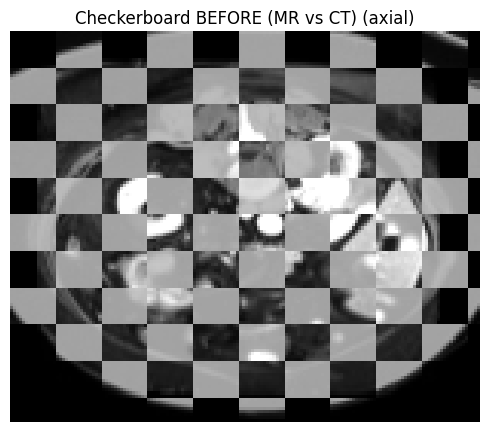

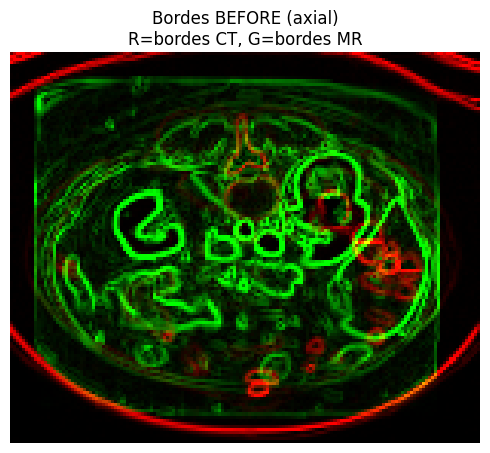

Metric final: -0.33768388162465174 | iters: 80
Dice AFTER : {1: 0.0003551977267343386, 2: 0.0005152425933872775, 3: 0.0006266318537852463, 4: 0.001126633618745914} | Mean: 0.0006559264481631941
ΔMean : -1.729005814121937e-05
[WARN] El registro ha empeorado. Se revierte a IDENTIDAD para el resto de visualizaciones/evaluación.
Dice AFTER(revert): {1: 0.00034439214785883114, 2: 0.0004927726675423022, 3: 0.0007925500297198409, 4: 0.0010631511800966796} | Mean: 0.0006732165063044135


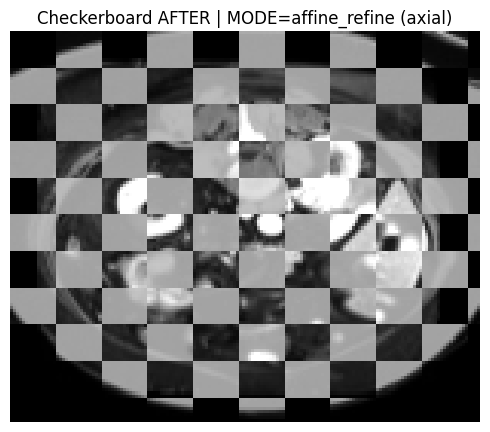

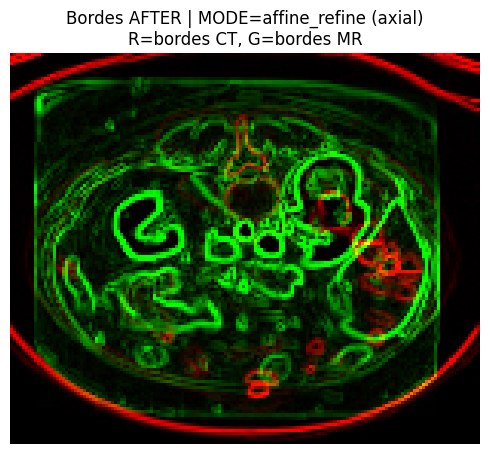

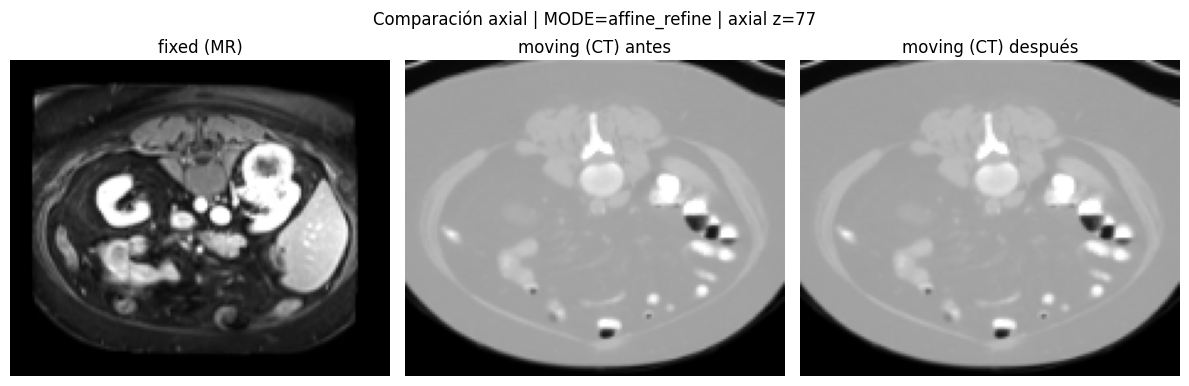

In [28]:
# === 0) Dice BEFORE (identidad) ===
moved_lab_id = sitk.Resample(
    moving_lab_p,
    fixed_lab_p,
    sitk.Transform(),
    sitk.sitkNearestNeighbor,
    0,
    sitk.sitkUInt16,
)
d_before = dice_per_label(fixed_lab_p, moved_lab_id, label_ids)
mean_before = float(np.mean(list(d_before.values())))
print("Dice BEFORE:", d_before, "| Mean:", mean_before)

show_checkerboard(
    fixed_p, moving_p, axis="axial", squares=10, title="Checkerboard BEFORE (MR vs CT)"
)
overlay_edges_on_fixed(fixed_p, moving_p, axis="axial", title="Bordes BEFORE")

# === 1) Selección de modo de registro ===
# - 'identity'        : no registrar (baseline visual)
# - 'rigid_refine'    : rígido (seguro)
# - 'affine_refine'   : refinado afín (baseline recomendado)
# - 'rigid_then_aff'  : rígido → afín (solo si hace falta)
MODE = "affine_refine"

# === 2) Máscaras en la métrica (empieza sin máscaras; si va bien, prueba fixed_mask) ===
USE_MASKS = False
USE_MOVING_MASK = False

fixed_m = fixed_mask_p if USE_MASKS else None
moving_m = moving_mask_p if (USE_MASKS and USE_MOVING_MASK) else None

# === 3) Ejecutar el modo seleccionado ===
if MODE == "identity":
    T_use = sitk.Transform()
    reg_info = None

elif MODE == "rigid_refine":
    T_use, reg_info = register_rigid_refine(
        fixed_p,
        moving_p,
        fixed_mask=fixed_m,
        moving_mask=moving_m,
        sampling=0.3,
        iters=150,
    )

elif MODE == "rigid_then_aff":
    T_rig, _ = register_rigid_refine(
        fixed_p,
        moving_p,
        fixed_mask=fixed_m,
        moving_mask=moving_m,
        sampling=0.3,
        iters=150,
    )
    T_use, reg_info = register_affine_small_refine(
        fixed_p,
        moving_p,
        init_transform=T_rig,
        fixed_mask=fixed_m,
        moving_mask=moving_m,
        sampling=0.3,
        iters=80,
    )

else:  # "affine_refine"
    T_use, reg_info = register_affine_small_refine(
        fixed_p,
        moving_p,
        init_transform=None,
        fixed_mask=fixed_m,
        moving_mask=moving_m,
        sampling=0.3,
        iters=80,
    )

if reg_info is not None:
    print(
        "Metric final:",
        reg_info.GetMetricValue(),
        "| iters:",
        reg_info.GetOptimizerIteration(),
    )

# === 4) Aplicar transform ===
moved_aff = sitk.Resample(
    moving_p, fixed_p, T_use, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)
moved_lab_aff = sitk.Resample(
    moving_lab_p, fixed_p, T_use, sitk.sitkNearestNeighbor, 0, sitk.sitkUInt16
)

# === 5) Dice AFTER ===
d_after = dice_per_label(fixed_lab_p, moved_lab_aff, label_ids)
mean_after = float(np.mean(list(d_after.values())))
print("Dice AFTER :", d_after, "| Mean:", mean_after)
print("ΔMean :", (mean_after - mean_before))

# === 6) Salvaguarda: si empeora, volver a identidad ===
if mean_after < mean_before:
    print(
        "[WARN] El registro ha empeorado. Se revierte a IDENTIDAD para el resto de visualizaciones/evaluación."
    )
    T_use = sitk.Transform()
    moved_aff = sitk.Resample(
        moving_p, fixed_p, T_use, sitk.sitkLinear, 0.0, sitk.sitkFloat32
    )
    moved_lab_aff = sitk.Resample(
        moving_lab_p, fixed_p, T_use, sitk.sitkNearestNeighbor, 0, sitk.sitkUInt16
    )
    d_after = dice_per_label(fixed_lab_p, moved_lab_aff, label_ids)
    mean_after = float(np.mean(list(d_after.values())))
    print("Dice AFTER(revert):", d_after, "| Mean:", mean_after)

# === 7) Visualización AFTER ===
show_checkerboard(
    fixed_p,
    moved_aff,
    axis="axial",
    squares=10,
    title=f"Checkerboard AFTER | MODE={MODE}",
)
overlay_edges_on_fixed(
    fixed_p, moved_aff, axis="axial", title=f"Bordes AFTER | MODE={MODE}"
)
show_triplet_slices(
    fixed_p, moving_p, moved_aff, title=f"Comparación axial | MODE={MODE}"
)

### 3.4 Retos para completar la sesión
1) Explora diferentes pares de imágenes, modificando `PAIR_INDEX`. 
2) Explora diferentes opciones de registro: `rigid_refine`, `affine_refine`, `rigid_then_aff` (con/sin máscaras para la métrica).
3) (Si tienes tiempo) añade un refinamiento BSpline (deformable).

Dice AFTER afín:   {1: 0.00034439214785883114, 2: 0.0004927726675423022, 3: 0.0007925500297198409, 4: 0.0010631511800966796}  | Mean: 0.0007

Iniciando BSpline 3D  mesh_size=[12, 12, 12]  ...
-------
Stop condition : LBFGSBOptimizerv4: User requested
Iterations     : 80
Metric value   : -0.8413999584677395
-------
Tiempo BSpline: 1600.7 s

─── Resumen Dice (mean) ───────────────────────
  BEFORE (identidad): 0.0007
  AFTER  afín       : 0.0007  (Δ = +0.0000)
  AFTER  BSpline    : 0.0001  (Δ = -0.0006)
───────────────────────────────────────────────
[WARN] BSpline empeoró respecto al afín. Se usa la transformación afín.


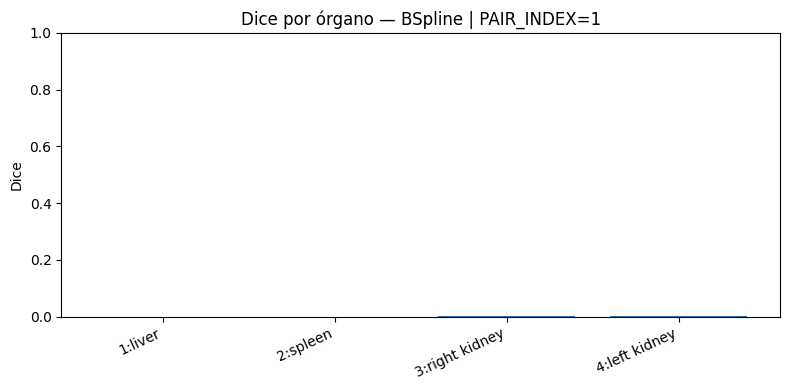

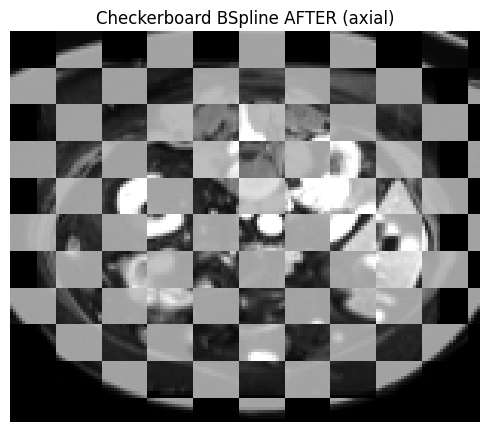

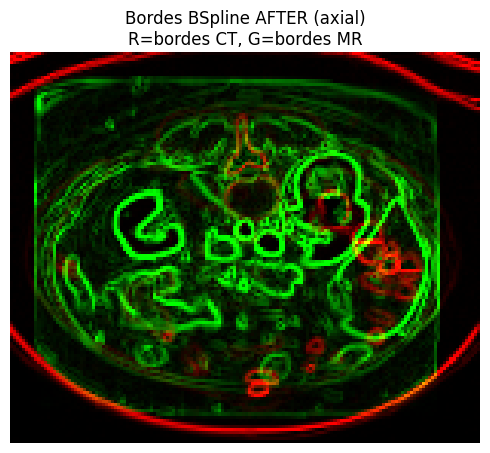

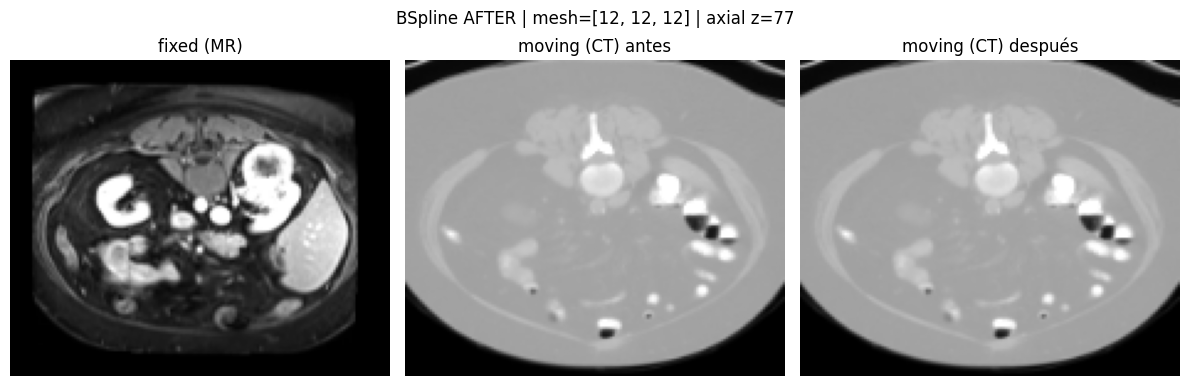

In [29]:
# ============================================================
# RETO 3.4.3: Refinamiento BSpline (deformable) sobre afín (MR-CT)
# ============================================================

import time


def register_bspline_multimodal(
    fixed,
    moving,
    init_transform=None,
    fixed_mask=None,
    moving_mask=None,
    mesh_size=[6, 6, 6],
    iters=80,
):
    """
    Refinamiento BSpline 3D sobre transformación inicial (afín/rígida).
    Usa MI de Mattes como métrica (robusta en multimodal MR-CT).
    Composición: T_moving_init (afín) + BSpline (deformable).
    """
    R = sitk.ImageRegistrationMethod()

    # Métrica: MI de Mattes (estándar en multimodal)
    R.SetMetricAsMattesMutualInformation(numberOfHistogramBins=64)
    R.SetMetricSamplingStrategy(R.RANDOM)
    R.SetMetricSamplingPercentage(0.15, seed=42)
    R.SetInterpolator(sitk.sitkLinear)

    # Máscaras opcionales
    if fixed_mask is not None:
        R.SetMetricFixedMask(sitk.Cast(fixed_mask > 0, sitk.sitkUInt8))
    if moving_mask is not None:
        R.SetMetricMovingMask(sitk.Cast(moving_mask > 0, sitk.sitkUInt8))

    # Optimizador LBFGSB (eficiente para BSpline con muchos parámetros)
    R.SetOptimizerAsLBFGSB(
        gradientConvergenceTolerance=1e-5,
        numberOfIterations=iters,
        maximumNumberOfCorrections=5,
        maximumNumberOfFunctionEvaluations=500,
        costFunctionConvergenceFactor=1e7,
    )

    # Transformación BSpline inicializada sobre la rejilla de fixed
    bspline_init = sitk.BSplineTransformInitializer(
        image1=fixed, transformDomainMeshSize=mesh_size, order=3
    )
    R.SetInitialTransformAsBSpline(bspline_init, inPlace=True)

    # Transformación inicial (afín) como "moving initial transform"
    if init_transform is not None:
        R.SetMovingInitialTransform(init_transform)

    # Multiresolución (3 niveles, más conservador que en monomodal)
    R.SetShrinkFactorsPerLevel([4, 2, 1])
    R.SetSmoothingSigmasPerLevel([2, 1, 0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    T_bsp = R.Execute(fixed, moving)

    print("-------")
    print("Stop condition :", R.GetOptimizerStopConditionDescription())
    print("Iterations     :", R.GetOptimizerIteration())
    print("Metric value   :", R.GetMetricValue())
    print("-------")

    return T_bsp, R


# ── Dice BEFORE (sobre el resultado afín) ──────────────────────────────────────
d_aff_eval = dice_per_label(fixed_lab_p, moved_lab_aff, label_ids)
mean_aff = float(np.mean(list(d_aff_eval.values())))
print(f"Dice AFTER afín:   {d_aff_eval}  | Mean: {mean_aff:.4f}")

# ── Parámetros del BSpline ──────────────────────────────────────────────────────
# mesh_size pequeño  → deformación suave
# mesh_size grande   → más detalle local
MESH_SIZE = [12, 12, 12]
USE_MASKS_BSP = False  # prueba True para restringir la métrica al abdomen

fixed_m_bsp = fixed_mask_p if USE_MASKS_BSP else None
moving_m_bsp = moving_mask_p if USE_MASKS_BSP else None

# ── Execución ──────────────────────────────────────────────────────────────────
print(f"\nIniciando BSpline 3D  mesh_size={MESH_SIZE}  ...")
t0 = time.time()

T_bsp, reg_bsp = register_bspline_multimodal(
    fixed_p,
    moving_p,
    init_transform=T_use,  # T_use = transformación afín/rígida previa
    fixed_mask=fixed_m_bsp,
    moving_mask=moving_m_bsp,
    mesh_size=MESH_SIZE,
    iters=80,
)

elapsed = time.time() - t0
print(f"Tiempo BSpline: {elapsed:.1f} s")

# ── Composición de transformaciones: afín + BSpline ───────────────────────────
# SimpleITK aplica T_use (vía SetMovingInitialTransform) + T_bsp en cadena
composite = sitk.CompositeTransform(3)
composite.AddTransform(T_use)
composite.AddTransform(T_bsp)

moved_bsp = sitk.Resample(
    moving_p, fixed_p, composite, sitk.sitkLinear, 0.0, sitk.sitkFloat32
)
moved_lab_bsp = sitk.Resample(
    moving_lab_p, fixed_p, composite, sitk.sitkNearestNeighbor, 0, sitk.sitkUInt16
)

# ── Evaluación cuantitativa ────────────────────────────────────────────────────
d_bsp = dice_per_label(fixed_lab_p, moved_lab_bsp, label_ids)
mean_bsp = float(np.mean(list(d_bsp.values())))

print("\n─── Resumen Dice (mean) ───────────────────────")
print(f"  BEFORE (identidad): {mean_before:.4f}")
print(f"  AFTER  afín       : {mean_aff:.4f}  (Δ = {mean_aff - mean_before:+.4f})")
print(f"  AFTER  BSpline    : {mean_bsp:.4f}  (Δ = {mean_bsp - mean_aff:+.4f})")
print("───────────────────────────────────────────────")

# ── Salvaguarda: revertir si BSpline empeora ──────────────────────────────────
if mean_bsp < mean_aff:
    print("[WARN] BSpline empeoró respecto al afín. Se usa la transformación afín.")
    moved_bsp = moved_aff
    moved_lab_bsp = moved_lab_aff
    d_bsp = d_aff_eval
    mean_bsp = mean_aff

# ── Evaluación visual ──────────────────────────────────────────────────────────
plot_dice(
    d_bsp, labels_map, title=f"Dice por órgano — BSpline | PAIR_INDEX={PAIR_INDEX}"
)

show_checkerboard(
    fixed_p, moved_bsp, axis="axial", squares=10, title="Checkerboard BSpline AFTER"
)
overlay_edges_on_fixed(fixed_p, moved_bsp, axis="axial", title="Bordes BSpline AFTER")
show_triplet_slices(
    fixed_p, moving_p, moved_bsp, title=f"BSpline AFTER | mesh={MESH_SIZE}"
)